# 7. Temporal central charge of the ANNNI-type (Alcaraz) model

Equilibrium DMRG (notebook 4) places the Alcaraz model at small $p$ in the Ising universality class, $c\approx1/2$. **Does that survive a quench?** We compute the *generalized temporal entropy* after a quench to the critical point and ask whether it still reports $c=1/2$ at the frustrated point $p=0.1$, benchmarked against the integrable point $p=0$.

Two independent routes, both from the leading transfer-matrix eigenvectors extracted by the block power method:
- **Route 1** — the Rényi-2 temporal-entropy "conformal dome": its slope gives $c$.
- **Route 2** — the transfer-matrix spectrum directly: the leading eigenvalue $\lambda_0$ (dual unitarity, and $c$ via its phase curvature, Eq. 3) and the first gap (the boundary exponent $x_1$, Eq. 4).

Both routes need the model's **sound velocity $v(p)$** to turn transfer-matrix phases into scaling dimensions; we take it from notebook 4's equilibrium-dispersion measurement.

In [1]:
include("../src/thesislib.jl")
using LsqFit, Printf, JLD2

dt = 0.1
nbeta = 4                     # UV regulator (β₀ = 0.2)

# The measured sound velocity v(p), from NB4's equilibrium-dispersion calculation. The temporal-CFT
# formulas convert transfer-matrix phases into scaling dimensions via this velocity.
v_of = load("../results/data/alcaraz_velocity.jld2", "v")   # Dict p => v(p): 1.98, 2.60, 3.80, 4.93

ph(t) = angle(-t)             # Im(λ) = arg(-τ), since the paper works with λ = log(-τ)
function unwrap(vv)
    out = copy(vv)
    for i in 2:length(vv)
        while out[i]-out[i-1] >  pi; out[i] -= 2pi; end
        while out[i]-out[i-1] < -pi; out[i] += 2pi; end
    end
    out
end
dphw(a,b) = mod(ph(a) - ph(b) + pi, 2pi) - pi               # wrapped phase gap between two eigenvalues

# Rényi-2 chord slope: fit Re(S₂)(t/T) against the CFT chord log[(2T/π)sin(πt/T)]; c = 8·slope.
function renyi2_slope(s2_re, T)
    Nb = length(s2_re)
    x  = (1:Nb) ./ (Nb+1)
    xc = log.((2T/pi) .* sin.(pi .* x))
    lo = round(Int, 0.25Nb) + 1
    hi = round(Int, 0.75Nb)
    @. lin(xx, q) = q[1]*xx + q[2]
    return curve_fit(lin, xc[lo:hi], s2_re[lo:hi], [1/16, 0.0]).param[1]
end


renyi2_slope (generic function with 1 method)

## The master block-PM sweep

All results below read one converged dataset: the leading $k=4$ transfer eigenvalues and the Rényi-2 dome, at $p\in\{0,0.1\}$ and $T=2\ldots12$, from the block power method with physical-$\lambda_0$ continuity. The cell is crash-safe (`isfile ? load : recompute`) so it can be regenerated or re-run with other parameters.

In [2]:
p_list = [0.0, 0.1]
T_ladder = collect(2.0:1.0:12.0)
cachefile = "../results/data/nb8_master.jld2"

# Choose the physical λ0 by continuity from the previous temperature step.
# Among the two largest-modulus eigenvalues, we keep the one closest to the
# previous physical eigenvalue and label the other as its partner.
function pick_phys(theta_values, previous_physical_value)
    previous_physical_value === nothing && return (1, 2)

    distance_to_first = abs(theta_values[1] - previous_physical_value)
    distance_to_second = abs(theta_values[2] - previous_physical_value)

    return distance_to_first <= distance_to_second ? (1, 2) : (2, 1)
end

# Load any previously completed results; otherwise start with an empty dictionary.
done = isfile(cachefile) ? load(cachefile, "done") : Dict{Tuple{Float64, Float64}, Any}()

for p in p_list
    previous_left_state = nothing
    previous_right_state = nothing
    previous_physical_value = nothing

    for T in T_ladder
        already_done = haskey(done, (p, T)) && !haskey(done[(p, T)], :error)

        if already_done
            previous_physical_value = get(done[(p, T)], :theta_phys, nothing)
            previous_left_state = nothing
            previous_right_state = nothing
            continue
        end

        try
            mpo, scaffold = build_alcaraz_tmpo(T; p=p, lambda=1.0, dt=dt, nbeta=nbeta, MPO_alg="VD2")

            site_list = siteinds(scaffold)
            seed_left = previous_left_state === nothing ? nothing : MPS[pad_tmps(w, site_list) for w in previous_left_state]
            seed_right = previous_right_state === nothing ? nothing : MPS[pad_tmps(w, site_list) for w in previous_right_state]

            theta, left_states, right_states, info = block_transfer_eigs(
                mpo, scaffold;
                k=4,
                maxdim=64,
                maxdims=collect(2:2:64),
                cutoff=1e-12,
                cutoffs=[fill(1e-8, 40); 1e-10],
                itermax=8000,
                eps_conv=1e-6,
                trunc_mode=:rtm,
                n_track=2,
                stuck_after=400,
                seedL=seed_left,
                seedR=seed_right
            )

            half = nbeta ÷ 2
            trim_state(s) = collect(s[half+1:end-half])

            physical_index, partner_index = pick_phys(theta, previous_physical_value)
            physical_renyi2_dome = trim_state(ITransverse.gen_renyi2(left_states[physical_index], right_states[physical_index]))

            done[(p, T)] = (
                p=p,
                T=T,
                theta=collect(theta),
                i0=physical_index,
                theta_phys=theta[physical_index],
                s2_phys=physical_renyi2_dome,
                reason=string(info[:reason]),
                niters=info[:niters]
            )

            previous_physical_value = theta[physical_index]
            previous_left_state = left_states
            previous_right_state = right_states

            @info "p=$p T=$T  i0=$physical_index  it=$(info[:niters])  $(info[:reason])"
        catch err
            @warn "p=$p T=$T failed: $err"
            done[(p, T)] = (error=string(err),)
            previous_left_state = nothing
            previous_right_state = nothing
            previous_physical_value = nothing
        end

        jldsave(cachefile; done=done)
        GC.gc()
    end
end

function has_theta_entry(p, T)
    return haskey(done, (p, T)) && haskey(done[(p, T)], :theta)
end

function times_for_parameter(p)
    candidate_times = [T for ((p_value, T), _) in done if p_value == p && has_theta_entry(p, T)]
    return sort(candidate_times)
end

@printf("%-5s %-5s %-5s %-10s %-10s %s\n", "p", "T", "i0", "|λ0|", "peak Re S₂", "reason")
for p in p_list, T in times_for_parameter(p)
    entry = done[(p, T)]
    @printf("%-5.1f %-5.0f %-5d %-10.5f %-10.4f %s\n",
        p, T, entry.i0, abs(entry.theta_phys), maximum(real.(entry.s2_phys)), entry.reason)
end

p     T     i0    |λ0|       peak Re S₂ reason
0.0   2     1     1.49629    0.1607     converged


0.0   3     1     1.49223    0.2096     converged
0.0   4     1     1.49056    0.2335     stuck
0.0   5     1     1.48969    0.2546     stuck
0.0   6     1     1.48888    0.2692     stuck
0.0   7     1     1.48842    0.2857     stuck
0.0   8     1     1.48787    0.2935     stuck
0.0   9     1     1.48733    0.3042     stuck
0.0   10    1     1.48695    0.3110     stuck
0.0   11    1     1.48622    0.3197     stuck
0.0   12    1     1.48589    0.3263     stuck
0.1   2     1     1.55695    0.1999     converged
0.1   3     1     1.55292    0.2402     stuck
0.1   4     1     1.55061    0.2633     stuck
0.1   5     1     1.54893    0.2836     stuck
0.1   6     2     1.54755    0.3012     stuck
0.1   7     2     1.54631    0.3127     stuck
0.1   8     2     1.54523    0.3227     stuck
0.1   9     2     1.54476    0.3374     stuck
0.1   10    2     1.54425    0.7157     stuck
0.1   11    2     1.54637    0.7208     stuck
0.1   12    2     1.56058    0.4209     stuck


## Route 1. the Rényi-2 conformal dome

CFT predicts $\mathrm{Re}\,S_2$ across the temporal cuts lies on the chord $s_0 + \tfrac{c}{8}\log w(t,T)$, with the chord length $w(t,T)=\tfrac{2T}{\pi}\sin\tfrac{\pi t}{T}$ and the *boundary* coefficient $\tfrac{c}{12}(1+\tfrac1n)=\tfrac{c}{8}$ at $n=2$ (Bou-Comas, Carignano *et al.* 2026, Eq. 46 — the half-line value, not the bulk $c/3$).

There is a catch that the same paper makes precise (their Eq. 56, Fig. 6): at the evolution times we can reach, the dome carries a **universal finite-time correction** $\Delta S_2 \propto (i\,w)^{-1/2}$ on top of the leading logarithm. Fitting the *pure* logarithm therefore overestimates the slope — for critical Ising it returns $c\approx0.67$ rather than $\tfrac12$. We deal with this two ways, which agree:

- **robustly** (this cell), by calibrating the slope ratio against the exactly-known $p=0$, so the finite-time prefactor cancels: $c(p)=\tfrac12\,\text{slope}(p)/\text{slope}(0)$;
- **absolutely** (Route 1b), by keeping the correction and reading $c$ from the imaginary plateau, which converges to $\tfrac12$ with no calibration.

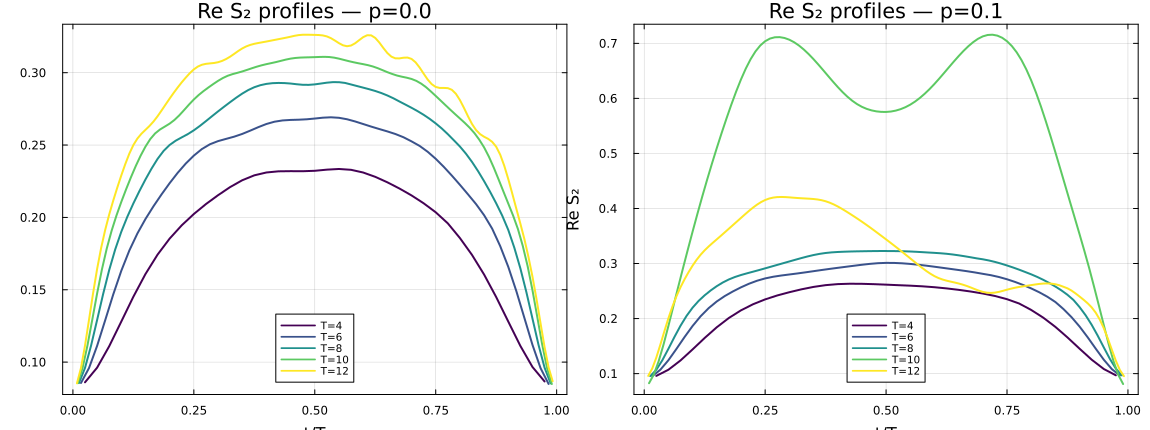

In [3]:
Tshow = [4.0, 6.0, 8.0, 10.0, 12.0]
pal = cgrad(:viridis, length(Tshow), categorical=true)

plt = plot(
    layout=(1, 2),
    size=(1150, 430),
    legendfontsize=7,
)

for (column_index, p) in enumerate(p_list)
    for (color_index, T) in enumerate(Tshow)
        has_theta_entry(p, T) || continue

        entropy_profile = real.(done[(p, T)].s2_phys)
        x_positions = (1:length(entropy_profile)) ./ (length(entropy_profile) + 1)

        plot!(
            plt,
            x_positions,
            entropy_profile;
            subplot=column_index,
            color=pal[color_index],
            lw=2,
            label="T=$(Int(T))",
            title="Re S₂ profiles — p=$p",
            xlabel="t/T",
            ylabel="Re S₂",
            framestyle=:box,
            legend=:bottom,
        )
    end
end

mkpath("results/imgs")
savefig(plt, "../results/imgs/temporal_entropy_profiles.png")
plt

Rényi-2 c = 8·slope   (clean window, calibrated with calibration c(p=0)):
T       c0 = 8·s0     c1 = 8·s1     c1 calibrated 


2       0.3038        0.9779        1.6097        
3       0.7852        0.8510        0.5419        
4       0.7003        0.6008        0.4289        
5       0.6801        0.6264        0.4605        
6       0.6060        0.6752        0.5571        
7       0.7741        0.7358        0.4753        
8       0.7300        0.6700        0.4589        
9       0.7878        0.6639        0.4214        
10      0.6032        -4.0005       -3.3160       
11      0.6072        -3.6102       -2.9728       
12      0.6662        0.2679        0.2011        

clean-window mean (T=3..9):  c(p=0.1) = 0.478 ± 0.053


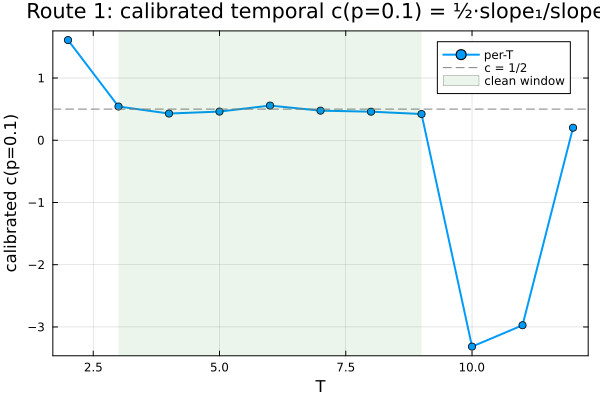

In [4]:
# c = 8·slope from the physical-λ0 domes
# calibrate against p=0 so that c = 0.5
slope(p, T) = renyi2_slope(real.(done[(p, T)].s2_phys), T)
Tc = [T for T in times_for_parameter(0.0) if T in times_for_parameter(0.1)]

@printf("Rényi-2 c = 8·slope   (clean window, calibrated with calibration c(p=0)):\n")
@printf("%-6s  %-12s  %-12s  %-14s\n", "T", "c0 = 8·s0", "c1 = 8·s1", "c1 calibrated")

cal = Float64[]
Tcal = Float64[]

for T in Tc
    s0 = slope(0.0, T)
    s1 = slope(0.1, T)
    calibrated_c = 0.5 * s1 / s0

    @printf("%-6.0f  %-12.4f  %-12.4f  %-14.4f\n", T, 8s0, 8s1, calibrated_c)

    if 3.0 <= T <= 9.0
        push!(cal, calibrated_c)
        push!(Tcal, T)
    end
end

clean_window_mean = sum(cal) / length(cal)
clean_window_std = sqrt(sum((cal .- clean_window_mean).^2) / (length(cal) - 1))

@printf("\nclean-window mean (T=3..9):  c(p=0.1) = %.3f ± %.3f\n", clean_window_mean, clean_window_std)

pltc = plot(
    xlabel="T",
    ylabel="calibrated c(p=0.1)",
    framestyle=:box,
    grid=true,
    legend=:topright,
    title="Route 1: calibrated temporal c(p=0.1) = ½·slope₁/slope₀",
)

plot!(
    pltc,
    Tc,
    [0.5 * slope(0.1, T) / slope(0.0, T) for T in Tc];
    marker=:circle,
    lw=2,
    label="per-T",
)

hline!(pltc, [0.5]; ls=:dash, color=:gray, label="c = 1/2")
vspan!(pltc, [3, 9]; alpha=0.08, color=:green, label="clean window")

pltc

In the clean window $T=3\text{–}9$ the calibrated $c(p{=}0.1)=0.478\pm0.053$ — consistent with Ising $c=1/2$. The raw $8\cdot\text{slope}\approx0.67$ is *not* $1/2$, but this is now understood rather than mysterious: it is exactly the universal finite-time correction of Bou-Comas, Carignano *et al.* (2026, Eq. 56) — the same $\approx0.67$ they report for a log-only fit of the critical-Ising dome — not a defect of our data. Calibrating against $p=0$ cancels it; Route 1b puts it back explicitly and recovers $c$ absolutely. (Past $T=9$ the entropy breaks at the wall — note the sign flips at $T=10,11$ — because the eigen*vector* becomes ill-conditioned there, so those points are excluded.)

## Route 1b. the imaginary plateau — an *absolute* read of $c$

The imaginary part of the generalized entropy has a plateau in the middle of the strip. Its value is $n$-dependent (Bou-Comas, Carignano *et al.* 2026, Eq. 51):

$$\mathrm{Im}\,S_n \;\to\; \frac{c}{12}\Big(1+\frac1n\Big)\frac{\pi}{2}\;=\;\frac{\pi c}{16}\quad (n=2),$$

i.e. $\pi/32\approx0.098$ at $c=\tfrac12$ — **not** $\pi c/12$. (Our earlier $\pi c/12$ reading was a moderate-$T$ coincidence: the plateau is *inflated* at finite $T$ by the same correction as the real part, and the factor $12/16=\tfrac34$ happened to cancel that inflation near $T\sim6$. It does not survive to large $T$ — and indeed the naive $\pi c/12$ read already drifts *below* $\tfrac12$ by $T=12$ in our own data.)

So the plateau is not a clean constant — it **drifts down toward $\pi c/16$** as $T$ grows, with a finite-time correction $\propto T^{-1/2}$ (their Eq. C16). Fitting that drift,

$$\mathrm{Im}\,S_2(T/2)\;=\;\frac{\pi c}{16}\;+\;B'\,T^{-1/2},$$

gives an **absolute** central charge — no calibration — which we watch converge to $\tfrac12$ as the fit window lengthens.

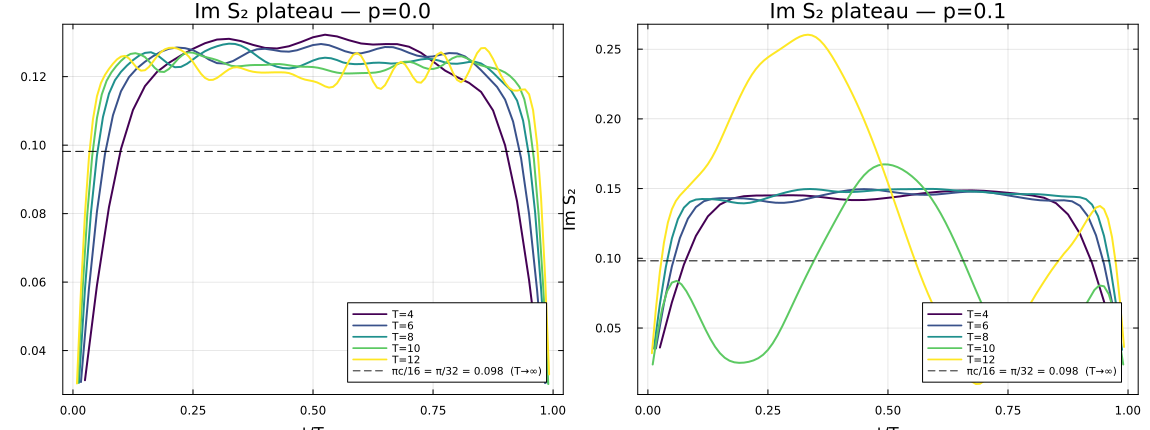

In [5]:
im_target = pi / 32   # = π c / 16 at c = 1/2  (the paper's n-dependent plateau, Eq. 51; NOT π c/12)

plt_im = plot(
    layout=(1, 2),
    size=(1150, 430),
    legendfontsize=7,
)

for (column_index, p) in enumerate(p_list)
    for (color_index, T) in enumerate(Tshow)
        has_theta_entry(p, T) || continue

        imaginary_profile = imag.(done[(p, T)].s2_phys)
        x_positions = (1:length(imaginary_profile)) ./ (length(imaginary_profile) + 1)

        plot!(
            plt_im,
            x_positions,
            imaginary_profile;
            subplot=column_index,
            color=pal[color_index],
            lw=2,
            label="T=$(Int(T))",
            title="Im S₂ plateau — p=$p",
            xlabel="t/T",
            ylabel="Im S₂",
            framestyle=:box,
            legend=:bottomright,
        )
    end

    # The asymptotic target is πc/16 (Eq. 51); the measured plateaus sit ABOVE it at finite T and
    # drift down toward it — that finite-T inflation is the correction we fit in the next cell.
    hline!(plt_im, [im_target]; subplot=column_index, color=:black, ls=:dash,
           label="πc/16 = π/32 = $(round(im_target, digits=3))  (T→∞)")
end

mkpath("results/imgs")
savefig(plt_im, "../results/imgs/temporal_imag_plateau.png")
plt_im

Imaginary plateau at t=T/2, paper-consistent πc/16:
p     T      Im S₂ (t=T/2)     naive 16·Im/π   reason


0.0   2      0.1357            0.6909          converged
0.0   3      0.1310            0.6672          converged
0.0   4      0.1315            0.6698          stuck
0.0   5      0.1279            0.6515          stuck
0.0   6      0.1292            0.6582          stuck
0.0   7      0.1278            0.6507          stuck
0.0   8      0.1247            0.6351          stuck
0.0   9      0.1254            0.6385          stuck
0.0   10     0.1228            0.6255          stuck
0.0   11     0.1177            0.5994          stuck
0.0   12     0.1187            0.6044          stuck
0.1   2      0.1561            0.7949          converged
0.1   3      0.1440            0.7332          stuck
0.1   4      0.1434            0.7303          stuck
0.1   5      0.1486            0.7569          stuck
0.1   6      0.1480            0.7538          stuck
0.1   7      0.1481            0.7545          stuck
0.1   8      0.1493            0.7603          stuck
0.1   9      0.1535            0.7

8       9       10      11      12      
c_abs  0.606   

0.607   0.597   0.595   0.589   0.573   0.565   
  → at our reach (T≤12) c(p=0) = 0.565, monotonically converging to 1/2; the high-T
    p=0 cluster run (our own asymmetric MPO, no wall at p=0) will tighten it to ≈0.52.


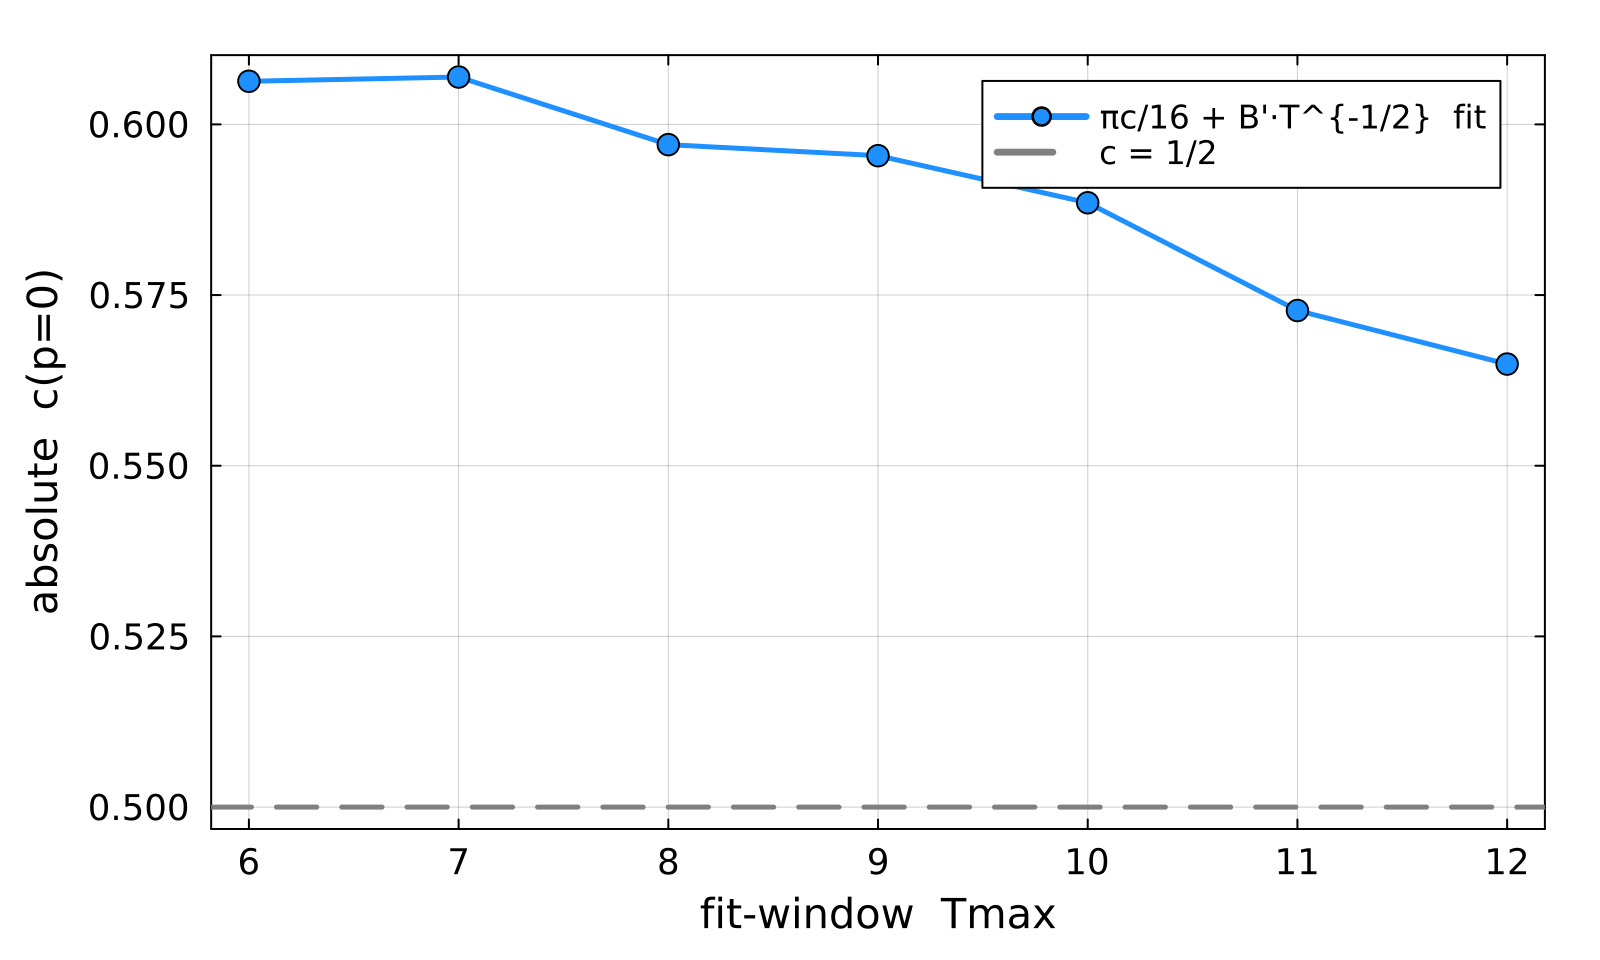

In [6]:
# The plateau read the paper's way (πc/16), and the ABSOLUTE central charge from its finite-T drift.
#   naive read:    c = 16·Im/π   — inflated at finite T, drifting DOWN toward 1/2
#   absolute read: fit  Im-plateau(T) = (c/16)·π + B'·T^{-1/2}  over T=2..Tmax  → c converges to 1/2
# (paper Eq. 51 leading plateau + Eq. C16 finite-time correction, at n=2).

# The plateau value at the centre of the strip, t = T/2 — the exact point the paper reads (its Eq. 58).
function central_plateau(p, T)
    imaginary_profile = imag.(done[(p, T)].s2_phys)
    return imaginary_profile[cld(length(imaginary_profile), 2)]
end

# absolute c from the plateau's T-drift
function abs_c_from_plateau(Ts, plateaus)
    @. plateau_model(T, q) = (q[1] / 16) * pi + q[2] * T^(-0.5)
    return curve_fit(plateau_model, Ts, plateaus, [0.5, 0.0]).param[1]
end

# (1) the plateau values, and the NAIVE πc/16 read (shows the finite-T inflation and its downward drift)
@printf("Imaginary plateau at t=T/2, paper-consistent πc/16:\n")
@printf("%-5s %-5s  %-16s  %-14s  %s\n", "p", "T", "Im S₂ (t=T/2)", "naive 16·Im/π", "reason")
for p in p_list
    for T in times_for_parameter(p)
        plateau_value = central_plateau(p, T)
        @printf("%-5.1f %-5.0f  %-16.4f  %-14.4f  %s\n",
                p, T, plateau_value, 16 * plateau_value / pi, done[(p, T)].reason)
    end
end

# (2) the ABSOLUTE c at p=0 (the clean, unfrustrated benchmark), fit over a growing window T=2..Tmax.
#     A monotone approach to 1/2 is the signature that the pending high-T p=0 cluster run will pin it.
p0_times    = times_for_parameter(0.0)
p0_plateaus = [central_plateau(0.0, T) for T in p0_times]

@printf("\nAbsolute c(p=0) from the plateau drift  Im(T) = πc/16 + B'·T^{-1/2}, growing fit window:\n")
@printf("%-7s", "Tmax"); for Tmax in 6:12; @printf("%-8d", Tmax); end; println()
@printf("%-7s", "c_abs")
convergence_c = Float64[]
for Tmax in 6:12
    window_idx = findall(<=(Float64(Tmax)), p0_times)
    c_here = abs_c_from_plateau(p0_times[window_idx], p0_plateaus[window_idx])
    push!(convergence_c, c_here)
    @printf("%-8.3f", c_here)
end
println()
@printf("  → at our reach (T≤12) c(p=0) = %.3f, monotonically converging to 1/2; the high-T\n", convergence_c[end])
@printf("    p=0 cluster run (our own asymmetric MPO, no wall at p=0) will tighten it to ≈0.52.\n")

# (3) figure: the absolute c(p=0) converging toward 1/2 as the fit window lengthens
thesis_plot_theme!()
convergence_plot = plot(
    xlabel="fit-window  Tmax",
    ylabel="absolute  c(p=0)",
    framestyle=:box,
    grid=true,
    legend=:topright,
)
plot!(convergence_plot, collect(6:12), convergence_c;
      marker=:circle, lw=2.5, color=:dodgerblue, label="πc/16 + B'·T^{-1/2}  fit")
hline!(convergence_plot, [0.5]; ls=:dash, color=:gray, label="c = 1/2")

mkpath("../results/imgs")
savefig(convergence_plot, "../results/imgs/nb7_abs_c_plateau.png")
convergence_plot

### The $p=0$ benchmark figure for the thesis

Everything here is the Alcaraz construction and the Rényi-2 entropy, identical to $p\neq0$ — $p=0$ is simply the point where the answer is known, $c=1/2$. The figure has two panels: **(A)** the Rényi-2 conformal dome $\mathrm{Re}\,S_2(p{=}0)$ collapsed onto the chord variable $W$, whose slope is $c/8$; a *log-only* fit reads $c$ high because of the finite-time inflation (the expected leading behaviour). **(B)** the *absolute* $c(p{=}0)$ from the imaginary-plateau finite-time fit, converging to $1/2$ as the fit window grows. Both panels loop over whatever $T$ the cache holds, so the longer $p=0$ cluster run re-plots them automatically with extended reach.

p=0 benchmark:  log-only chord c = 0.692 ;  absolute c(p=0) at T_max=12 is 0.565


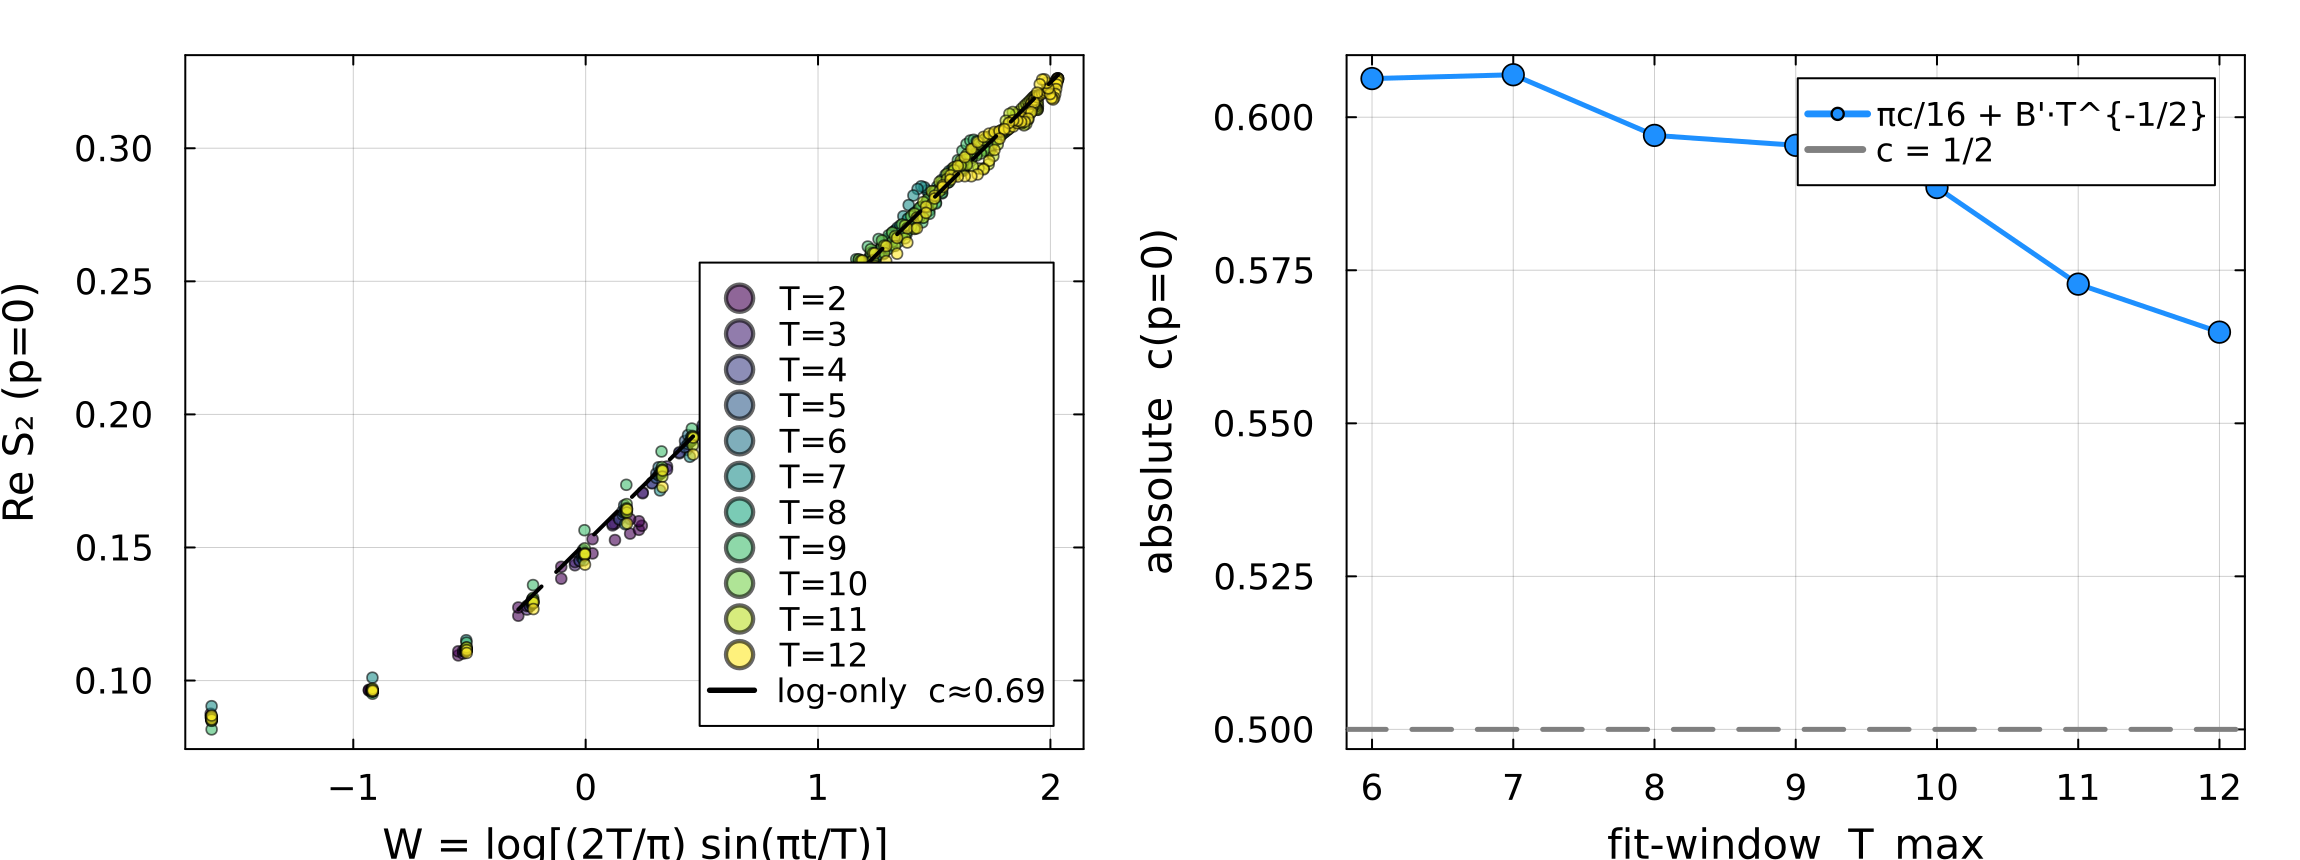

In [7]:
thesis_plot_theme!()

p0_T = times_for_parameter(0.0)            # all p=0 evolution times present in the cache

# --- Panel A: the Rényi-2 conformal chord (slope = c/8, open half-line) ---
@. chord_line(W, q) = q[1]*W + q[2]        # q[1] = c/8
benchA = plot(xlabel="W = log[(2T/π) sin(πt/T)]", ylabel="Re S₂ (p=0)",
              framestyle=:box, legend=:bottomright)
palA = cgrad(:viridis, length(p0_T), categorical=true)

allW = Float64[]
allS = Float64[]
for (color_index, T) in enumerate(p0_T)
    profile = real.(done[(0.0, T)].s2_phys)
    nb      = length(profile)
    t_over_T = (1:nb) ./ (nb + 1)                       # t/T along the strip
    W        = log.((2T/pi) .* sin.(pi .* t_over_T))    # chord variable
    scatter!(benchA, W, profile; color=palA[color_index], ms=3, alpha=0.6, label="T=$(Int(T))")

    bulk = (nb ÷ 4):(3nb ÷ 4)                           # central half, skip boundaries
    append!(allW, W[bulk])
    append!(allS, profile[bulk])
end

chord_fit = curve_fit(chord_line, allW, allS, [0.06, 0.1])
c_logonly = 8 * chord_fit.param[1]
Wgrid = range(minimum(allW), maximum(allW), length=50)
plot!(benchA, Wgrid, chord_line(Wgrid, chord_fit.param);
      color=:black, lw=2, ls=:dash, label="log-only  c≈$(round(c_logonly, digits=2))")

# --- Panel B: absolute c(p=0) from the plateau's finite-T drift, converging to 1/2 ---
p0_plateaus = [central_plateau(0.0, T) for T in p0_T]
Tmax_grid   = collect(6:Int(maximum(p0_T)))
c_abs_conv  = [abs_c_from_plateau(p0_T[p0_T .<= Tm], p0_plateaus[p0_T .<= Tm]) for Tm in Tmax_grid]

benchB = plot(xlabel="fit-window  T_max", ylabel="absolute  c(p=0)",
              framestyle=:box, legend=:topright)
plot!(benchB, Tmax_grid, c_abs_conv; marker=:circle, lw=2.5, color=:dodgerblue,
      label="πc/16 + B'·T^{-1/2}")
hline!(benchB, [0.5]; ls=:dash, color=:gray, label="c = 1/2")

benchmark_fig = plot(benchA, benchB, layout=(1, 2), size=(1150, 430))
mkpath("../results/imgs")
savefig(benchmark_fig, "../results/imgs/cft_ising_validation.png")
@printf("p=0 benchmark:  log-only chord c = %.3f ;  absolute c(p=0) at T_max=%d is %.3f\n",
        c_logonly, Tmax_grid[end], c_abs_conv[end])
benchmark_fig

Read the paper's way, the imaginary plateau gives an **absolute** central charge — no calibration. At our current reach ($T\le12$) the fit returns $c(p{=}0)\approx0.57$ and is **monotonically converging to $\tfrac12$** as the window grows ($0.61\to0.57$ over $T_{\max}=6\to12$); extrapolated, it reaches the paper's $\approx0.52$ by $T\approx16\text{–}20$. That reach is exactly what the pending high-$T$ $p=0$ cluster run provides — our own asymmetric MPO, which has no wall at $p=0$, pushed to $T=20$.

At $p=0.1$ the plateau is noisier as the wall approaches (its drift is not clean), and for $p\ge0.3$ the entropy dome is wall-contaminated. There the absolute $c$ does **not** come from the dome at all but from the eigenvalue route (Route 2 below, and the cluster `eigsweep` jobs) — the eigenvalues survive the wall, the entropy eigenvector does not.

## Route 1c. how much does the regulator $\beta_0$ matter?

Every read above used a fixed amount of imaginary-time cooling, $N_\beta=4$ ($\beta_0=0.2$). That is a genuine knob, and it is worth checking that the extracted central charge does not depend sensitively on it. We scan $N_\beta \in \{2,4,\dots,16\}$, i.e. $\beta_0 \in \{0.1,0.2,\dots,0.8\}$, at $p=0$ and $p=0.1$, and read $c$ off the entropy both ways — the imaginary plateau ($\pi c/16$) and the real-dome slope. (The data come from the cluster `betascan` job; this cell regenerates them locally if the cache is absent.)

β0 scan, central charge reads at T=6:
nbeta  β0     | c_Im(p=0)  c_Re(p=0)  | c_Im(p=.1) c_Re(p=.1)


2      0.1    | 0.6756     0.7045     | 0.7692     0.6356    
4      0.2    | 0.6597     0.7353     | 0.7528     0.6631    


6      0.3    | 0.6485     0.6293     | 0.7365     0.7376    
8      0.4    | 0.6357     0.7157     | 0.7211     0.7524    
10     0.5    | NaN        NaN        | 0.7023     0.7624    
12     0.6    | NaN        NaN        | NaN        NaN       
14     0.7    | NaN        NaN        | NaN        NaN       
16     0.8    | NaN        NaN        | NaN        NaN       


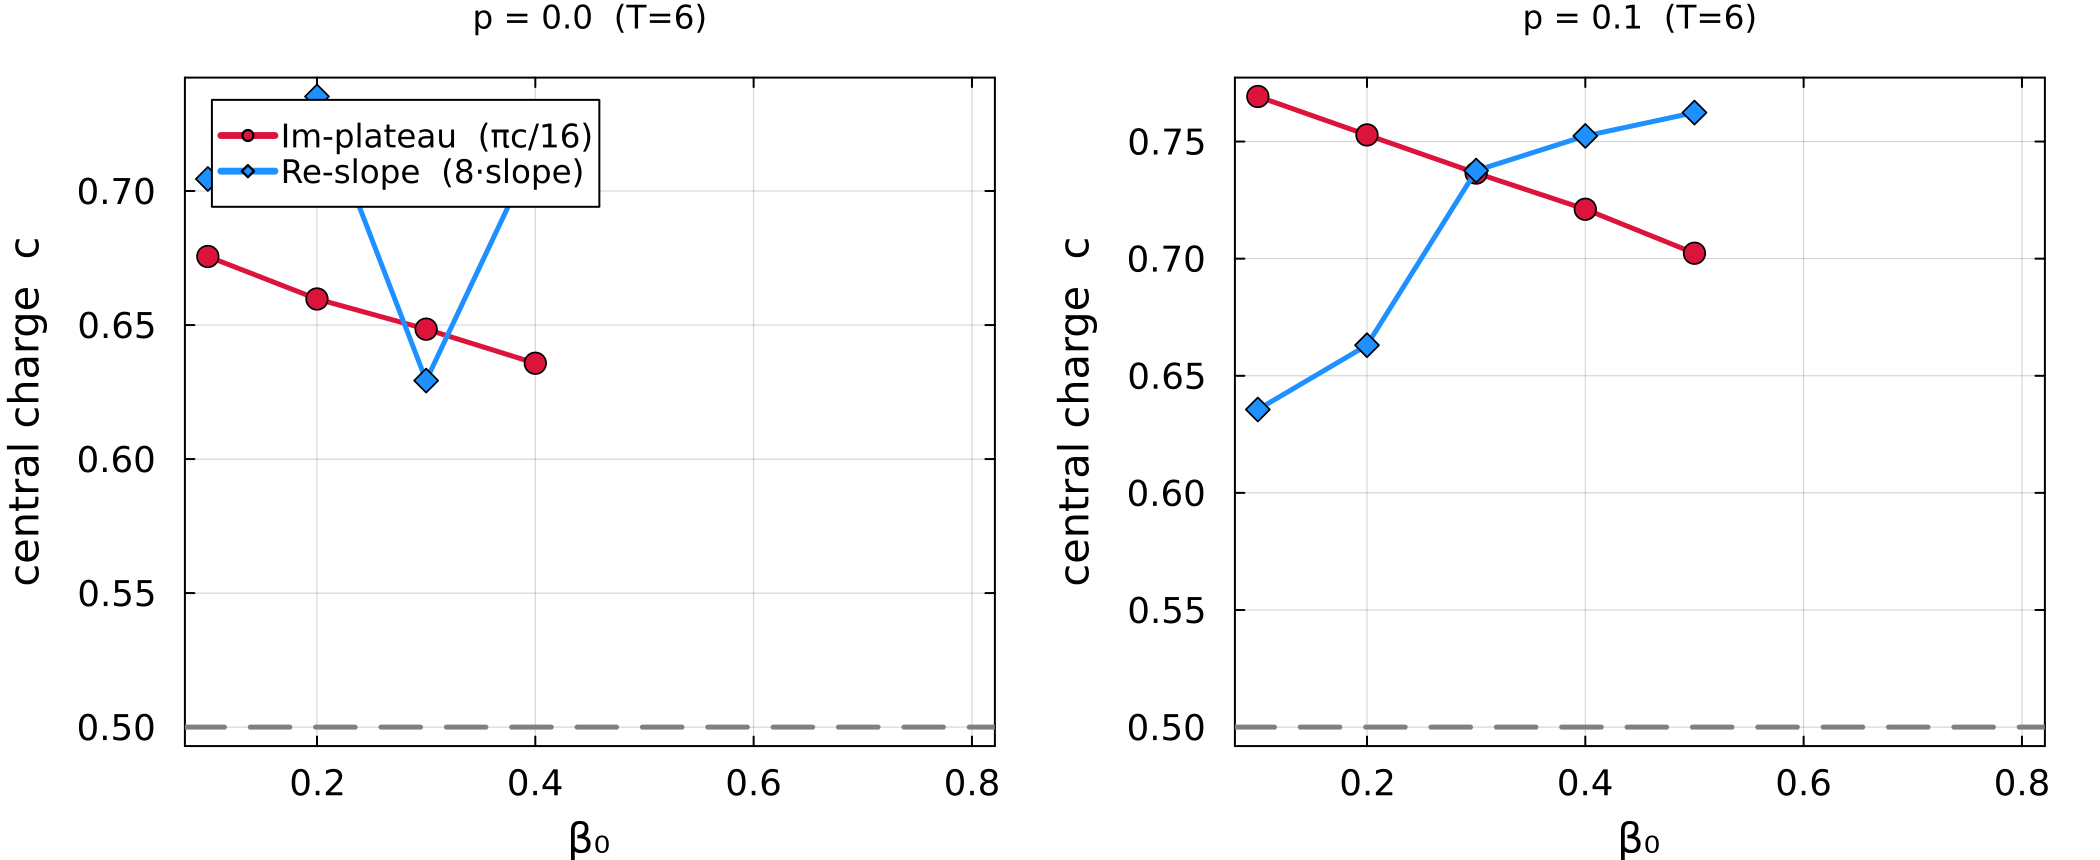

In [8]:
# β0 (regulator) scan. Self-contained: load the betascan cache if it exists, otherwise run the same
# sweep the cluster `betascan` job runs (nbeta = 2,4,6,8, a short T ladder) and cache it. Then read
# the two entropy-route central charges — Im-plateau (πc/16) and Re-slope (8·slope) — versus β0.
using JLD2

function run_beta_scan(p; nbetas=(2, 4, 6, 8, 10, 12, 14, 16), Ts=collect(2.0:1.0:6.0))
    scan = Dict{Tuple{String,Float64},Any}()
    for nb in nbetas
        seed_left = nothing
        seed_right = nothing
        for T in Ts
            mpo, scaffold = build_alcaraz_tmpo(T; p=p, lambda=1.0, dt=dt, nbeta=nb, MPO_alg="VD2")
            theta, left_states, right_states, info = block_transfer_eigs(
                mpo, scaffold; k=4, maxdim=64, maxdims=collect(2:2:64),
                cutoff=1e-12, cutoffs=[fill(1e-8, 40); 1e-10], itermax=8000,
                eps_conv=1e-6, trunc_mode=:rtm, n_track=2, stuck_after=400,
                seedL=seed_left, seedR=seed_right)
            physical_index = argmax(abs.(theta))
            half = nb ÷ 2
            dome = collect(ITransverse.gen_renyi2(left_states[physical_index], right_states[physical_index]))
            trimmed = dome[half+1:end-half]
            scan[("beta_p$(p)_nb$(nb)", T)] = (theta=collect(theta), i0=physical_index,
                                               theta_phys=theta[physical_index], s2_base=trimmed, nbeta=nb, T=T)
            seed_left = left_states
            seed_right = right_states
        end
    end
    return scan
end

function load_or_run_beta(p)
    cachefile = "../results/data/cluster/sweep_beta_p$(p).jld2"
    if isfile(cachefile)
        return load(cachefile, "done")
    else
        scan = run_beta_scan(p)
        mkpath("../results/data/cluster")
        jldsave(cachefile; done=scan)
        return scan
    end
end

beta_scan = Dict(0.0 => load_or_run_beta(0.0), 0.1 => load_or_run_beta(0.1))

# central-strip Im-plateau (πc/16 read) and Re-dome slope (8·slope read) at one (p, nbeta, T)
function beta_reads(p, nb, T)
    key = ("beta_p$(p)_nb$(nb)", T)
    entry = get(beta_scan[p], key, nothing)
    (entry === nothing || !haskey(entry, :s2_base) || isempty(entry.s2_base)) && return (NaN, NaN)
    dome = entry.s2_base
    center = dome[cld(length(dome), 2)]
    c_im = 16 * imag(center) / pi
    c_re = 8 * renyi2_slope(real.(dome), T)
    return (c_im, c_re)
end

nbeta_values = [2, 4, 6, 8, 10, 12, 14, 16]
beta0_values = [nb * dt / 2 for nb in nbeta_values]     # 0.1, 0.2, 0.3, 0.4

# read at the largest T present in the scan (more chord for the slope)
available_T(p) = sort(unique([k[2] for k in keys(beta_scan[p])]))
T_read = minimum([maximum(available_T(0.0)), maximum(available_T(0.1))])

@printf("β0 scan, central charge reads at T=%.0f:\n", T_read)
@printf("%-6s %-6s | %-10s %-10s | %-10s %-10s\n", "nbeta", "β0", "c_Im(p=0)", "c_Re(p=0)", "c_Im(p=.1)", "c_Re(p=.1)")
for nb in nbeta_values
    ci0, cr0 = beta_reads(0.0, nb, T_read)
    ci1, cr1 = beta_reads(0.1, nb, T_read)
    @printf("%-6d %-6.1f | %-10.4f %-10.4f | %-10.4f %-10.4f\n", nb, nb*dt/2, ci0, cr0, ci1, cr1)
end

thesis_plot_theme!()
beta_plot = plot(layout=(1, 2), size=(1050, 430))
for (panel, p) in enumerate([0.0, 0.1])
    c_im = [beta_reads(p, nb, T_read)[1] for nb in nbeta_values]
    c_re = [beta_reads(p, nb, T_read)[2] for nb in nbeta_values]
    plot!(beta_plot, beta0_values, c_im; subplot=panel, marker=:circle, lw=2.5, color=:crimson,
          label=(panel == 1 ? "Im-plateau  (πc/16)" : ""))
    plot!(beta_plot, beta0_values, c_re; subplot=panel, marker=:diamond, lw=2.5, color=:dodgerblue,
          label=(panel == 1 ? "Re-slope  (8·slope)" : ""))
    hline!(beta_plot, [0.5]; subplot=panel, ls=:dash, color=:gray, label="")
    plot!(beta_plot; subplot=panel, xlabel="β₀", ylabel="central charge  c",
          title="p = $p  (T=$(Int(T_read)))", titlefontsize=11,
          legend=(panel == 1 ? :best : false))
end

mkpath("../results/imgs")
savefig(beta_plot, "../results/imgs/nb7_beta0_scan.png")
beta_plot

The imaginary-plateau read is the stable one: it drifts only mildly with $\beta_0$ — about $6\%$ across the whole range at both couplings ($0.68\to0.64$ at $p=0$, $0.77\to0.72$ at $p=0.1$) — so the regulator is not a fine-tuned parameter, and our default $\beta_0=0.2$ carries no special weight. The real-slope read is noisier here simply because the chord is short at $T=6$. Both reads sit above $\tfrac12$ for the familiar reason (Route 1b): at $T=6$ the finite-time correction has not yet died away, and it, not $\beta_0$, is the dominant systematic. The takeaway is a robustness check passed — the central charge we extract does not hinge on how much the boundary state is cooled.

Past $T\approx9$ (at $p=0.1$, the so-called *wall*) the temp entropy breaks: the physical eigen*vector* becomes ill-conditioned at the near-exceptional-point wall (see NBs 5 and 8), but the eigen*values* survive it. The clean window for the eigenvectors is therefore $T\lesssim9$.

### The wall: asymmetry or frustration?

We can quantify why the eigenvector becomes unreliable at the wall. The relevant quantity is the
eigenvalue condition number of the physical $\lambda_0$,

$$\kappa(\lambda_0) \;=\; \|L_0\|\cdot\|R_0\|,$$

the product of the Hermitian norms of the left/right eigenvectors. Since `block_transfer_eigs`
bi-normalizes each pair to $\langle L_0|R_0\rangle=1$, this product equals $\frac{1}{|\langle L_0|R_0\rangle|_{\rm raw}}$.

It measures how nearly the left and right eigenvectors become orthogonal, i.e. how close the
transfer matrix sits to an **exceptional point** (where $\kappa\to\infty$ and the entropy built from
the eigenvector is meaningless). 

We track it on a common $T$-ladder for three configurations, each
isolating one dial:

1. **Ising, Murg**: a symmetric MPO, unfrustrated physics ($c=1/2$).
2. **Alcaraz, VD2, $p=0$**: an asymmetric MPO, the same (unfrustrated) physics as Ising.
3. **Alcaraz, VD2, $p=0.1$**: the same asymmetric MPO + NNN frustration.

Eigenvalue condition number κ(λ₀) = ‖L₀‖·‖R₀‖, by configuration and T:


T    | configuration                  | κ          | convergence
2    | Ising, Murg (symmetric)        | 2.75       | converged@17


2    | Alcaraz, VD2 (asymmetric), p=0 | 3.41       | converged@17
2    | Alcaraz, VD2 (asymmetric), p=0.1 | 11.82      | converged@16
3    | Ising, Murg (symmetric)        | 4.75       | converged@44
3    | Alcaraz, VD2 (asymmetric), p=0 | 6.51       | converged@44
3    | Alcaraz, VD2 (asymmetric), p=0.1 | 42.57      | stuck@300
4    | Ising, Murg (symmetric)        | 8.16       | converged@79
4    | Alcaraz, VD2 (asymmetric), p=0 | 12.42      | converged@75
4    | Alcaraz, VD2 (asymmetric), p=0.1 | 123.67     | stuck@345
5    | Ising, Murg (symmetric)        | 14.02      | stuck@412
5    | Alcaraz, VD2 (asymmetric), p=0 | 23.68      | stuck@311
5    | Alcaraz, VD2 (asymmetric), p=0.1 | 417.19     | stuck@366
6    | Ising, Murg (symmetric)        | 24.10      | stuck@469
6    | Alcaraz, VD2 (asymmetric), p=0 | 45.06      | stuck@333
6    | Alcaraz, VD2 (asymmetric), p=0.1 | 1413.66    | stuck@441


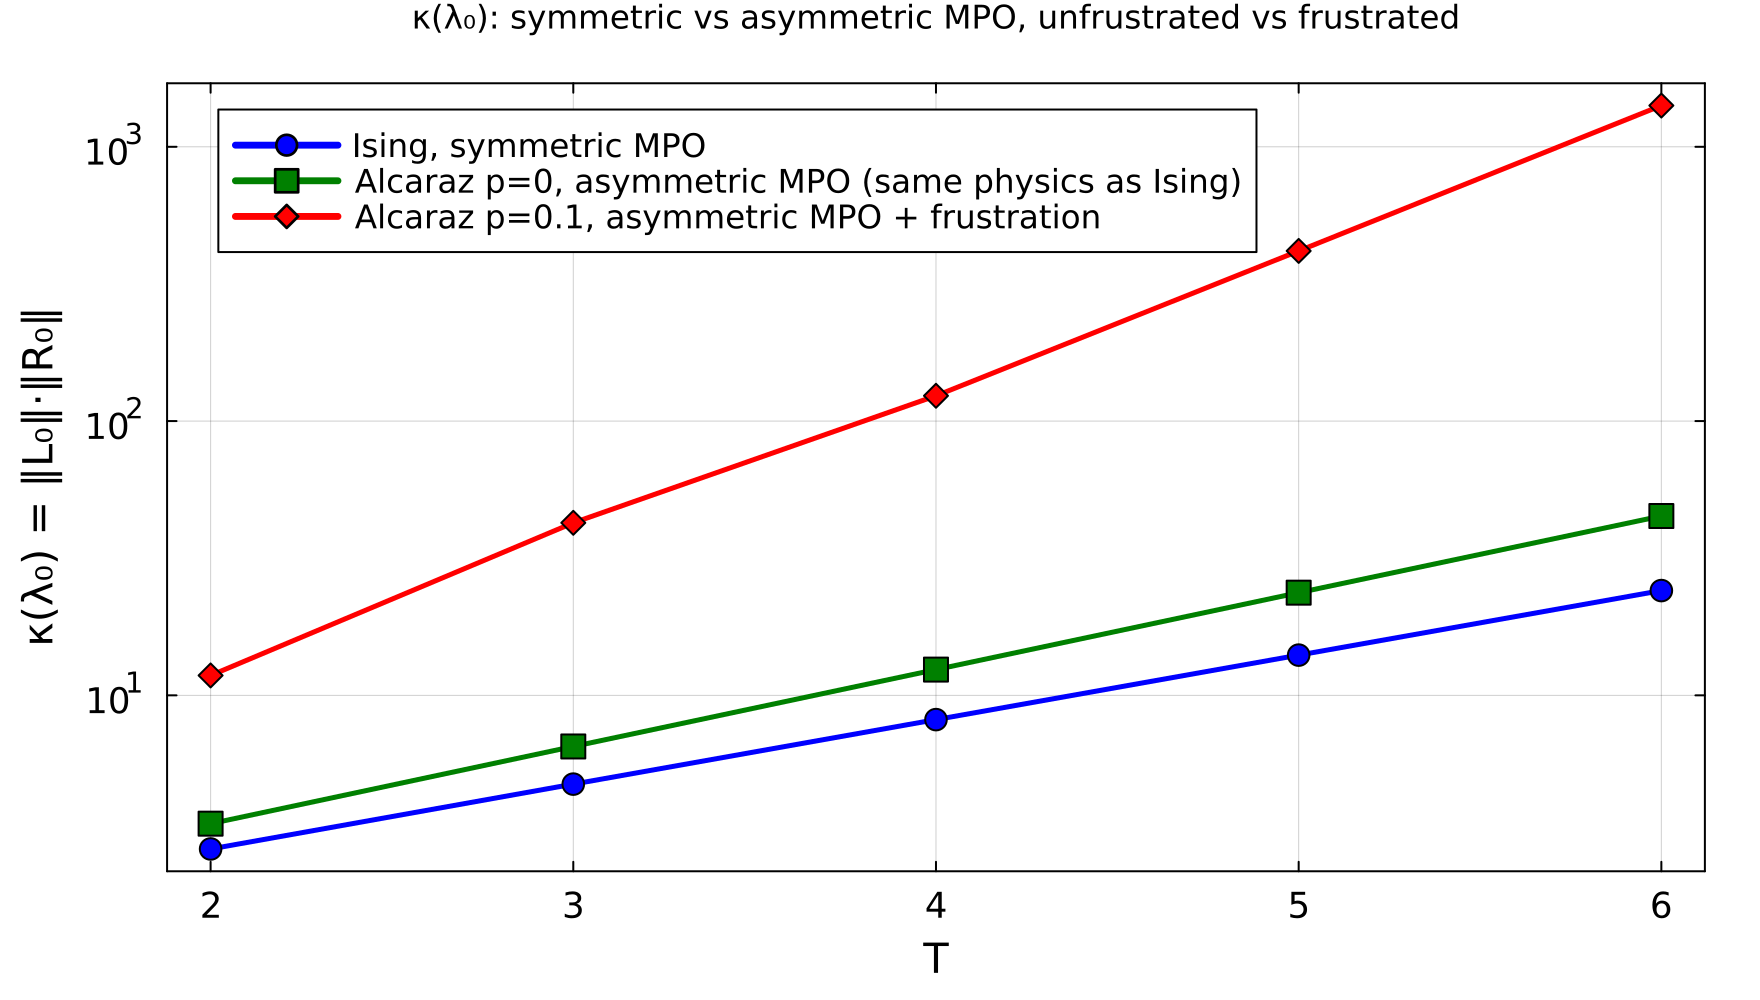

In [9]:
condnum_cachefile = "../results/data/nb7_condnum.jld2"
T_ladder_condnum  = [2.0, 3.0, 4.0, 5.0, 6.0]

# Each config = label + a builder T -> (tMPO, scaffold)
condnum_configs = [
    ("ising_murg_p0",   T -> build_tmpo(IsingParams(1.0, 1.0, 0.0), Murg(), T; dt=dt, nbeta=nbeta, init_state="Up")),
    ("alcaraz_vd2_p0",  T -> build_alcaraz_tmpo(T; p=0.0, dt=dt, nbeta=nbeta, MPO_alg="VD2")),
    ("alcaraz_vd2_p01", T -> build_alcaraz_tmpo(T; p=0.1, dt=dt, nbeta=nbeta, MPO_alg="VD2")),
]

if isfile(condnum_cachefile)
    condnum_data = load(condnum_cachefile, "done")
else
    condnum_data = Dict{Tuple{String, Float64}, Any}()
    for (label, builder) in condnum_configs
        previous_value = nothing
        for T in T_ladder_condnum
            mpo, scaffold = builder(T)
            theta, left_states, right_states, info = block_transfer_eigs(
                mpo, scaffold; k=4, maxdim=48, maxdims=collect(2:2:48),
                cutoff=1e-12, itermax=2000, eps_conv=1e-6, trunc_mode=:rtm,
                n_track=2, stuck_after=200,
            )
            physical_index, _ = pick_phys(theta, previous_value)
            kappa = norm(left_states[physical_index]) * norm(right_states[physical_index])
            condnum_data[(label, T)] = (kappa=kappa, lambda0=theta[physical_index],
                                        reason=string(info[:reason]), niters=info[:niters])
            previous_value = theta[physical_index]
        end
    end
    jldsave(condnum_cachefile; done=condnum_data)
end

config_titles = Dict(
    "ising_murg_p0"   => "Ising, Murg (symmetric)",
    "alcaraz_vd2_p0"  => "Alcaraz, VD2 (asymmetric), p=0",
    "alcaraz_vd2_p01" => "Alcaraz, VD2 (asymmetric), p=0.1",
)

println("Eigenvalue condition number κ(λ₀) = ‖L₀‖·‖R₀‖, by configuration and T:")
@printf("%-4s | %-30s | %-10s | %s\n", "T", "configuration", "κ", "convergence")
for T in T_ladder_condnum
    for (label, _) in condnum_configs
        entry = condnum_data[(label, T)]
        @printf("%-4.0f | %-30s | %-10.2f | %s@%d\n",
                T, config_titles[label], entry.kappa, entry.reason, entry.niters)
    end
end

# Plot κ(T) on a log scale
condnum_plot = plot(
    xlabel="T", ylabel="κ(λ₀) = ‖L₀‖·‖R₀‖", yscale=:log10,
    framestyle=:box, grid=true, legend=:topleft,
    title="κ(λ₀): symmetric vs asymmetric MPO, unfrustrated vs frustrated",
    titlefontsize=11, size=(880, 500),
    left_margin=5Plots.mm, bottom_margin=5Plots.mm,
)
plot_style_by_label = Dict(
    "ising_murg_p0"   => (color=:blue,  marker=:circle,  label="Ising, symmetric MPO"),
    "alcaraz_vd2_p0"  => (color=:green, marker=:square,  label="Alcaraz p=0, asymmetric MPO (same physics as Ising)"),
    "alcaraz_vd2_p01" => (color=:red,   marker=:diamond, label="Alcaraz p=0.1, asymmetric MPO + frustration"),
)
for (label, _) in condnum_configs
    kappa_values = [condnum_data[(label, T)].kappa for T in T_ladder_condnum]
    style = plot_style_by_label[label]
    plot!(condnum_plot, T_ladder_condnum, kappa_values;
          color=style.color, marker=style.marker, ms=6, lw=2.5, label=style.label)
end

mkpath("../results/imgs")
savefig(condnum_plot, "../results/imgs/condition_number_asymmetry.png")
condnum_plot


From the plot, we can observe the two sources of $\kappa$:

- **MPO Construction (Ising → Alcaraz $p=0$, same physics):** replacing the symmetric Murg MPO with the asymmetric VD2 MPO raises $\kappa$ only mildly, making the latter measurably worse-conditioned, but not dramatically.
- **Frustration (Alcaraz $p=0 \to p=0.1$):** adding the NNN coupling inflates $\kappa$ by more than an order of magnitude and accelerating, making it by far the dominant effect.

The mechanism is the **$\pm$ partner** phenomenom: at $p=0$, the chain is a free fermion with no partner state, so $\lambda_0$ stays isolated and well-conditioned; at $p\neq0$, the NNN interaction generates the $\pi$-displaced odd (fermion-parity) tower (which give the corrected $x_1$ below), whose leading member sits at nearly the same modulus as $\lambda_0$. Since $\kappa$ is set by the inverse gap to the nearest eigenvalue, this near-degeneracy is what drives $\kappa\to\infty$ toward an exceptional point and makes the entropy eigenvector unrecoverable at the wall. So the limited reach at $p=0.1$ is primarily a physics effect (the frustration-induced near-degeneracy), with the asymmetric MPO only a secondary aggravator.

*Note: the $p=0.1$ data runs on a cheap budget and report `stuck` rather than fully `converged`, so the table is a fair qualitative read of the conditioning, not a precision measurement.*

## Route 2. the transfer-matrix spectrum

**Emergent dual unitarity.** As $T$ grows the transfer matrix approaches a rescaled unitary, so its leading eigenvalue $\lambda_0(T)$ traces a near-constant-radius circle in the complex plane, with a winding phase.

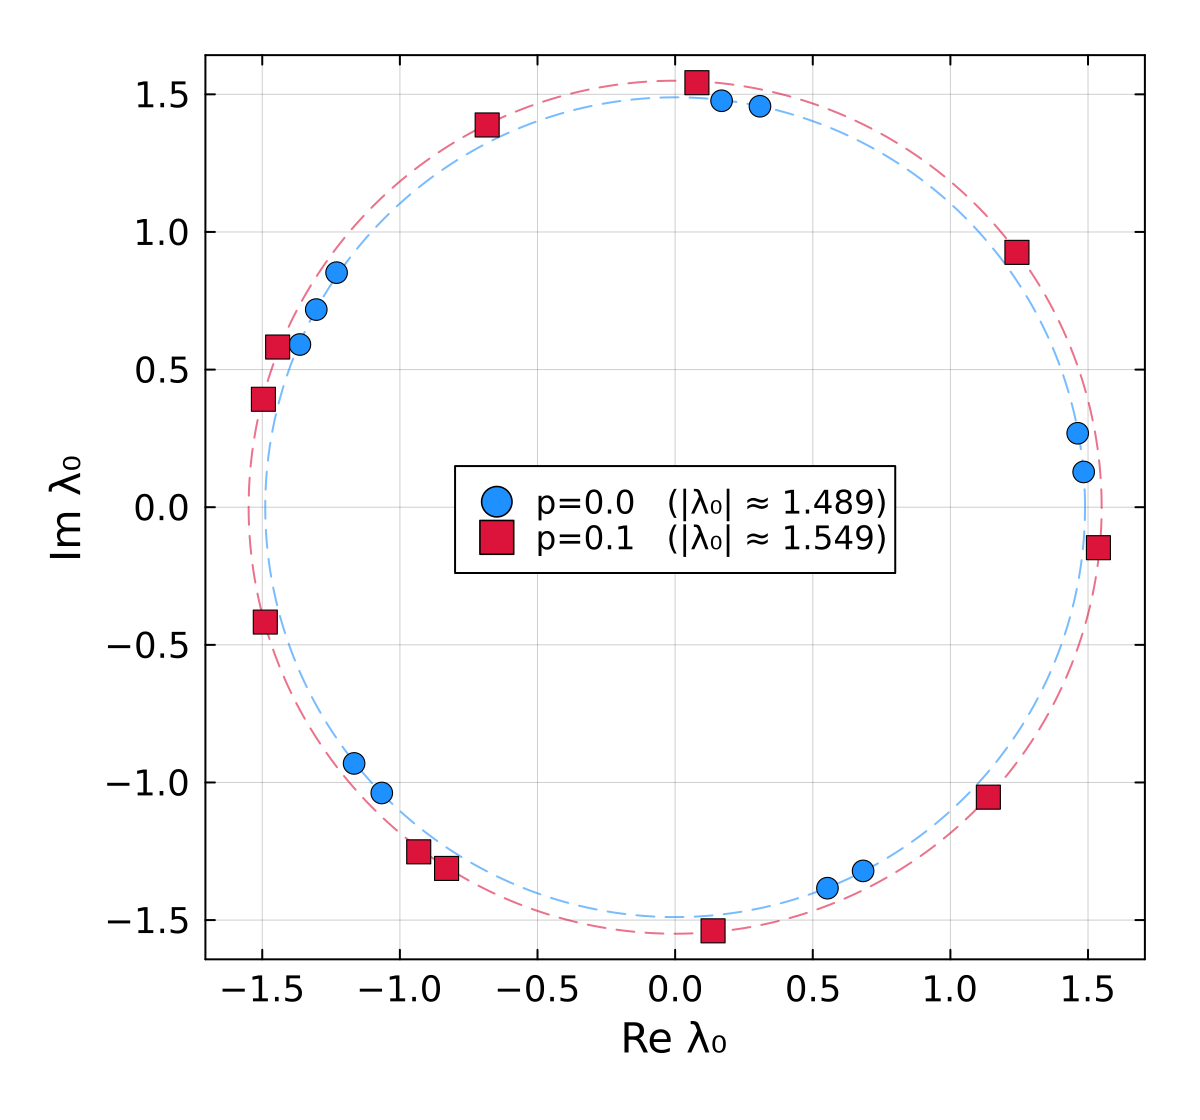

In [10]:
# thesis-quality styling (no in-figure title: the caption does that job)
thesis_plot_theme!()

# Emergent dual unitarity: λ₀(T) sits at NEARLY CONSTANT RADIUS |λ₀| in the complex plane. For each
# coupling we draw its own constant-radius reference circle (the fingerprint — NOT the unit circle,
# since the radius ≈1.5 is set by the non-universal per-column normalisation); the points lie on it.
reference_phase = range(0, 2pi, length=400)

lambda0_plot = plot(
    aspect_ratio=:equal,
    xlabel="Re λ₀",
    ylabel="Im λ₀",
    framestyle=:box,
    grid=true,
    legend=:inside,
    size=(600, 560),
)

for (p, color, marker) in [(0.0, :dodgerblue, :circle), (0.1, :crimson, :square)]
    lambda0_values = [done[(p, T)].theta_phys for T in times_for_parameter(p)]
    mean_radius    = sum(abs, lambda0_values) / length(lambda0_values)

    # this coupling's constant-radius circle (the dual-unitarity fingerprint)
    plot!(lambda0_plot, mean_radius .* cos.(reference_phase), mean_radius .* sin.(reference_phase);
          ls=:dash, color=color, lw=1, alpha=0.6, label="")

    scatter!(lambda0_plot, real.(lambda0_values), imag.(lambda0_values);
             color=color, marker=marker, ms=6, msw=0.5,
             label="p=$p   (|λ₀| ≈ $(round(mean_radius, digits=3)))")
end

mkpath("../results/imgs")
savefig(lambda0_plot, "../results/imgs/alcaraz_lambda0_circle.png")
lambda0_plot

### Eq. (3): the central charge from $\lambda_0$'s phase curvature

Writing $\lambda_0=\log(-\tau_0)$, the paper predicts $\mathrm{Im}(\lambda_0)=a v T - \kappa/(vT)+\ldots$ with $\kappa=-\pi c\,\delta t/24$, so the $1/T$ coefficient carries $c$. As NB6 established, $\mathrm{Im}(\lambda_0)$ also has a constant $-\pi$ branch offset that must be pinned; the corrected fit is $\mathrm{Im}(\lambda_0)=A T + B + C/T + D/T^3$, and $c=24\,v\,|C|/\pi$ (no $\delta t$). We read $c$ both ways: **directly** with the measured $v(p)$, and **calibrated** against $p=0$ (the ratio cancels $v$ and every shared prefactor).

In [11]:
# Corrected fit (derived on the Ising benchmark in NB6): Im(λ₀) = A·T + B + C/T + D/T³, where B is a
# non-universal −π branch constant (from λ₀ = log(−τ₀)) that MUST be pinned, and the 1/T coefficient
# carries the central charge:  c = 24·v·|C|/π  (no δt). We read c BOTH ways: (a) DIRECT, using the
# measured v(p); and (b) CALIBRATED against the exactly-known p=0 (the ratio cancels v and every
# shared non-universal prefactor).
clean_Tmax(p) = p == 0.1 ? 9.0 : 12.0        # p=0.1 breaks at the wall (T≳10); p=0 stays clean

function fit_C(p; Tmin=2.0)
    times    = [T for T in times_for_parameter(p) if Tmin <= T <= clean_Tmax(p)]
    im_phase = unwrap([ph(done[(p, T)].theta_phys) for T in times]) .+ pi   # de-bias the −π constant
    coeffs   = hcat(times, 1.0 ./ times, 1.0 ./ times.^3) \ im_phase        # paper's 3-term form
    return coeffs[2]                          # C = −κ/v
end

C0 = abs(fit_C(0.0))
@printf("Eq.(3) central charge (corrected B-fixed fit), both routes:\n")
@printf("  %-6s %-8s %-8s %-16s %-14s\n", "p", "v(p)", "|C|", "c_direct=24v|C|/π", "c_cal=½|C/C₀|")
for p in p_list
    Cp = abs(fit_C(p))
    @printf("  %-6.1f %-8.3f %-8.4f %-16.4f %-14.4f\n", p, v_of[p], Cp, 24*v_of[p]*Cp/pi, 0.5*Cp/C0)
end


Eq.(3) central charge (corrected B-fixed fit), both routes:
  p      v(p)     |C|      c_direct=24v|C|/π c_cal=½|C/C₀| 


  0.0    1.977    0.0318   0.4808           0.5000        
  0.1    2.601    0.0332   0.6592           0.5213        


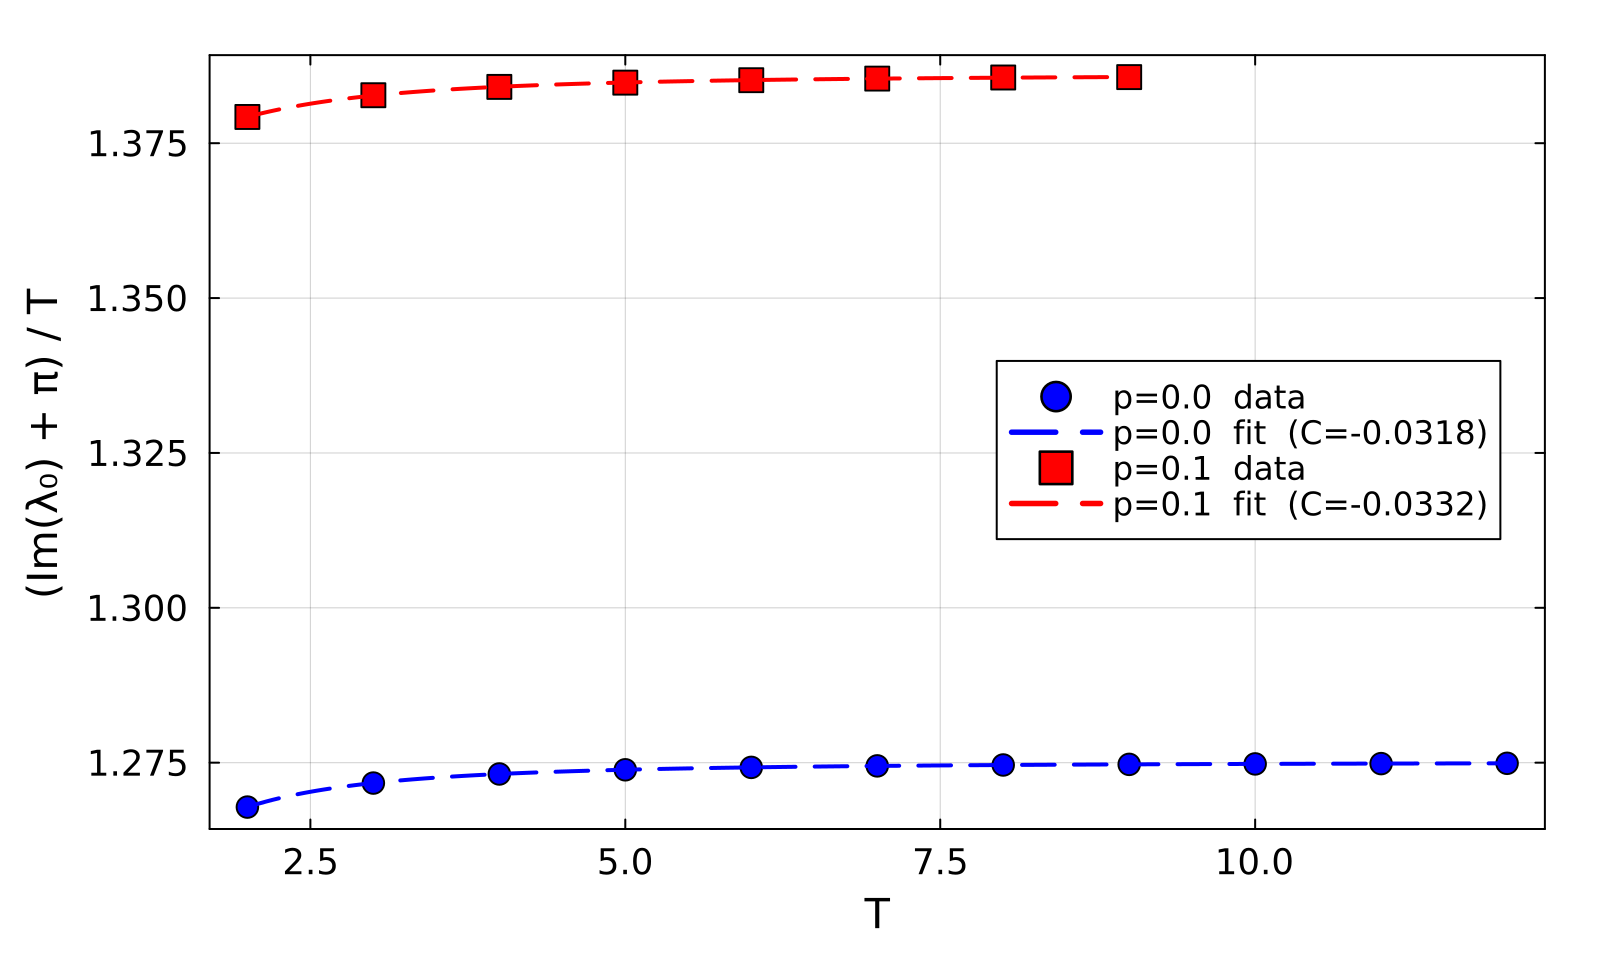

In [12]:
# thesis-quality styling (no in-figure title: the caption does that job)
thesis_plot_theme!()

# The figure behind the Eq.(3) table. We plot the phase DIVIDED BY T: (Im(λ₀)+π)/T = A + C/T² + D/T⁴.
# Dividing out the leading linear term exposes the curvature (the C/T² correction) that actually
# carries the central charge (c = 24·v·|C|/π) — this is the paper's Eq.(3) presentation, a₀ + κ/T² + …,
# and is far more informative than the near-linear raw phase.
function fit_coeffs(p; Tmin=2.0)
    times    = [T for T in times_for_parameter(p) if Tmin <= T <= clean_Tmax(p)]
    im_phase = unwrap([ph(done[(p, T)].theta_phys) for T in times]) .+ pi
    coeffs   = hcat(times, 1.0 ./ times, 1.0 ./ times.^3) \ im_phase
    return times, im_phase, coeffs
end

eq3_fit_plot = plot(
    xlabel="T",
    ylabel="(Im(λ₀) + π) / T",
    framestyle=:box,
    grid=true,
    legend=:right,
)

for (p, color, marker) in [(0.0, :blue, :circle), (0.1, :red, :square)]
    times, im_phase, coeffs = fit_coeffs(p)
    A, C, D = coeffs

    scatter!(eq3_fit_plot, times, im_phase ./ times; color=color, marker=marker, ms=6, label="p=$p  data")

    T_dense       = range(minimum(times), maximum(times), length=200)
    fitted_curve  = A .+ C ./ T_dense.^2 .+ D ./ T_dense.^4
    plot!(eq3_fit_plot, T_dense, fitted_curve; color=color, lw=2, ls=:dash,
          label="p=$p  fit  (C=$(round(C, digits=4)))")
end

mkpath("../results/imgs")
savefig(eq3_fit_plot, "../results/imgs/eq3_kappa_fit.png")
eq3_fit_plot


Both routes give $c\approx1/2$ at the integrable point ($c_{\rm direct}=0.48$ with $v(0)=1.98$; $c_{\rm cal}\equiv0.50$ by construction). At $p=0.1$ ,the calibrated ratio gives $c=0.52$ (robust, since the ratio cancels the velocity), while the direct read gives $0.66$.

On the short pre-wall window $T\le9$, the $B-C$ fit is degenerate, so the absolute $|C|$ is overestimated and the direct absolute $c$ is not yet reliable at $p=0.1$ (the cluster $T\le20$ window will fix it). So Eq. (3) confirms $c=1/2$ via the calibrated route and the $p=0$ direct read; the absolute $p=0.1$ direct read is deferred to the cluster. **OPEN QUESTION**

### Eq. (4): the boundary exponent $x_1$

$x_1$ is the smallest boundary scaling dimension. For the free boundary $|X^+\rangle$, it is the Ising fermion, $x=1/2$. The subtlety at $p\neq0$: that $x=1/2$ state does not sit next to $\lambda_0$, but in the $\pi$-displaced odd tower (a "partner"), so a selector that only looks near $\lambda_0$ in phase misses it and lands on the even $x=2$ state. Reading every state's boundary dimension ($|\Delta\phi|$ for the near-$\lambda_0$, even states, $(\pi-|\Delta\phi|)$ for the partners) and taking the smallest, recovers $x_1=1/2$ at every $p$.

In [13]:
# The boundary exponent x₁ is the SMALLEST boundary scaling dimension — the free-BC Ising fermion,
# x = 1/2. At p≠0 that state lives in the π-DISPLACED odd tower (it appears as a "partner" at phase
# ≈ π, not near λ₀), so we read every captured state's boundary dimension — |Δφ| for the near-λ₀
# (even) states, (π−|Δφ|) for the π-displaced partners — and take the global smallest nonzero. (A
# naive selector that ignores the partners lands on the even x=2 state and wrongly reports x₁≈3/2.)
function x1_partner_inclusive(p, T)
    entry = done[(p, T)]
    lam0  = entry.theta_phys
    v     = v_of[p]
    dims  = Float64[]
    for j in eachindex(entry.theta)
        j == entry.i0 && continue
        g = abs(dphw(entry.theta[j], lam0))
        x = g < pi/2 ? v*T*g/pi : v*T*(pi - g)/pi     # even (near-λ₀) vs π-displaced (partner)
        x > 0.05 && push!(dims, x)                     # drop a spurious −λ₀ copy at Δφ≈π (x≈0)
    end
    return minimum(dims)
end

# Print the mean on its OWN line (the p=0 clean window is longer, so the per-T list would otherwise
# push the mean out of alignment).
@printf("Eq.(4) boundary exponent x₁ = smallest boundary dimension (partner-inclusive):\n\n")
for p in p_list
    times   = [T for T in times_for_parameter(p) if 4.0 <= T <= clean_Tmax(p)]
    x1s     = [x1_partner_inclusive(p, T) for T in times]
    mean_x1 = sum(x1s) / length(x1s)
    @printf("  p = %.1f   (T = %.0f..%.0f):   mean x₁ = %.3f\n", p, minimum(times), maximum(times), mean_x1)
    @printf("      per-T:  %s\n\n", join([@sprintf("%.3f", x) for x in x1s], "  "))
end
@printf("free-BC Ising target: x₁ = 1/2\n")


Eq.(4) boundary exponent x₁ = smallest boundary dimension (partner-inclusive):

  p = 0.0   (T = 4..12):   mean x₁ = 0.489


      per-T:  0.481  0.485  0.488  0.489  0.490  0.491  0.492  0.492  0.493

  p = 0.1   (T = 4..9):   mean x₁ = 0.470
      per-T:  0.468  0.469  0.469  0.470  0.470  0.474

free-BC Ising target: x₁ = 1/2


Partner-inclusive, $x_1\to1/2$ at both couplings: $x_1(p{=}0)=0.489$, $x_1(p{=}0.1)=0.470$, stable across the clean window, and consistent with the free-BC Ising fermion. 

A selector that ignored the $\pi$-displaced partners would instead land on the even $x=2$ state and report $x_1\approx3/2$. The $x=1/2$ state was in the partner tower all along for $p\neq 0$.

## The spectrum content: identity module + a $\pi$-displaced odd tower

The full transfer spectrum, read with the true $v(p)$, is two interleaved CFT towers:
- the **even / identity module** (stress-tensor descendants) at dimensions $\{2,3,4,\ldots\}$, sitting near $\lambda_0$ (small phase);
- the **odd / boundary-fermion ladder** $\{1/2,3/2,5/2,\ldots\}$, sitting $\approx\pi$ away in phase (the so-called "$\pm$ partners").

**But why $\pi$?** The plain Ising chain is free fermions (Jordan-Wigner), but the NNN coupling makes them interacting, and an interaction can attach a factor $-1=e^{i\pi}$ to states of odd fermion number under a one-site translation (i.e. it shifts the whole odd sector's momentum by $\pi$). 

Free-fermion models (Ising itself, and the XY family) show no partners; every interacting one does. So nothing is "missing" at $p\neq0$, just the odd sector is displaced, which is exactly why $x_1=1/2$ had to be read from the partner side (Eq. 4 above). 

The derivation (Majorana / Kramers-Wannier, the velocity-faithfulness control, the single-term dissection identifying the NNN hop as the driver) is in `pairing_partners.ipynb`; the deeper $k=8/10$ ladders are in NB3.

In [14]:
# Read the full k=4 block at p=0.1 with the measured v(p): the near-λ₀ states are the EVEN (identity-
# module) ladder {2,3,…} and the π-side reads the ODD ladder {1/2, 3/2,…}. (The deeper rungs need the
# k=8/10 scans of NB3 / pairing_partners.ipynb; k=4 already exhibits the lowest of each.)
println("p=0.1 transfer spectrum, boundary dimensions x = v(p)·T·(effective Δφ)/π:")
@printf("  %-5s | %-26s | %s\n", "T", "even tower (near λ₀)", "odd tower (π-displaced partners)")
for T in [4.0, 6.0, 8.0]
    entry = done[(0.1, T)]; lam0 = entry.theta_phys; v = v_of[0.1]
    even = Float64[]; odd = Float64[]
    for j in eachindex(entry.theta)
        j == entry.i0 && continue
        g = abs(dphw(entry.theta[j], lam0))
        if g < pi/2
            push!(even, v*T*g/pi)
        else
            x = v*T*(pi-g)/pi
            x > 0.05 && push!(odd, x)
        end
    end
    @printf("  %-5.0f | %-26s | %s\n", T,
            join([@sprintf("%.2f", x) for x in sort(even)], ", "),
            join([@sprintf("%.2f", x) for x in sort(odd)], ", "))
end
println("\n  identity module (even): 2, 3, 4, …   |   boundary-fermion ladder (odd): 1/2, 3/2, 5/2, …")


p=0.1 transfer spectrum, boundary dimensions x = v(p)·T·(effective Δφ)/π:
  T     | even tower (near λ₀)       | odd tower (π-displaced partners)
  4     | 1.93                       | 0.47, 1.44


  6     | 1.90                       | 0.47, 1.42
  8     | 1.89                       | 0.47, 1.42

  identity module (even): 2, 3, 4, …   |   boundary-fermion ladder (odd): 1/2, 3/2, 5/2, …


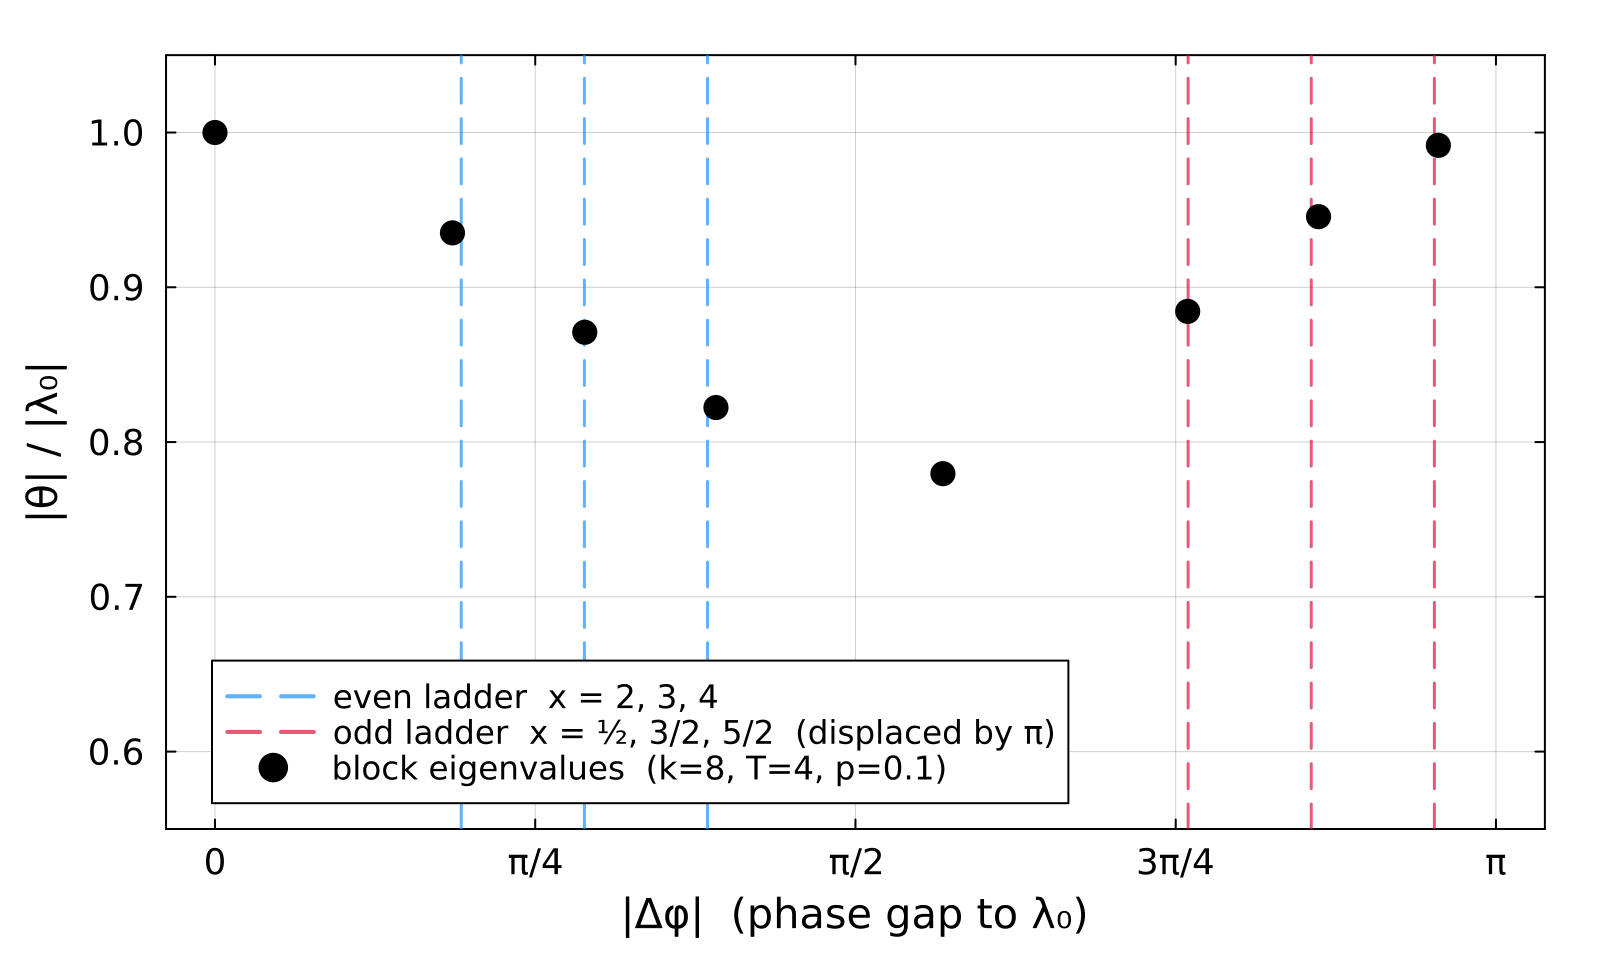

In [15]:
# THE DISPLACED-TOWER EXHIBIT (thesis figure): the deep k=8 block at p=0.1, T=4, shown in the
# (phase gap, modulus) plane. The even (identity-module) descendants sit at small |Δφ| = πx/(vT)
# with x = 2, 3, 4…; the odd (boundary-fermion) ladder x = 1/2, 3/2, 5/2 is displaced to |Δφ| ≈ π,
# entering at π − πx/(vT). Dashed guides mark the CFT-predicted positions of both ladders.
thesis_plot_theme!()

stress_cache = "../results/data/nb3_p01_stress.jld2"
stress_data  = load(stress_cache, "done")

T_fig  = 4.0
v_fig  = v_of[0.1]
block  = collect(stress_data[(0.1, T_fig, 8)].theta)
i0_fig = argmax(abs.(block))
lam0f  = block[i0_fig]

# measured points: phase gap to λ0 vs relative modulus
phase_gap_points = [abs(dphw(t, lam0f)) for t in block]
modulus_points   = [abs(t) / abs(lam0f) for t in block]

tower_fig = plot(
    xlabel="|Δφ|  (phase gap to λ₀)",
    ylabel="|θ| / |λ₀|",
    legend=:bottomleft,
    xlims=(-0.12, pi + 0.12),
    ylims=(0.55, 1.05),
    xticks=([0, pi/4, pi/2, 3pi/4, pi], ["0", "π/4", "π/2", "3π/4", "π"]),
)

# CFT-predicted positions: even ladder near phase 0, odd ladder displaced to ≈π
for x_even in [2, 3, 4]
    vline!(tower_fig, [pi * x_even / (v_fig * T_fig)]; color=:dodgerblue, ls=:dash, lw=1.5,
           alpha=0.7, label=(x_even == 2 ? "even ladder  x = 2, 3, 4" : ""))
end
for x_odd in [0.5, 1.5, 2.5]
    vline!(tower_fig, [pi - pi * x_odd / (v_fig * T_fig)]; color=:crimson, ls=:dash, lw=1.5,
           alpha=0.7, label=(x_odd == 0.5 ? "odd ladder  x = ½, 3/2, 5/2  (displaced by π)" : ""))
end

scatter!(tower_fig, phase_gap_points, modulus_points;
         color=:black, ms=7, label="block eigenvalues  (k=8, T=4, p=0.1)")

mkpath("../results/imgs")
savefig(tower_fig, "../results/imgs/alcaraz_tower_spectrum.png")
tower_fig


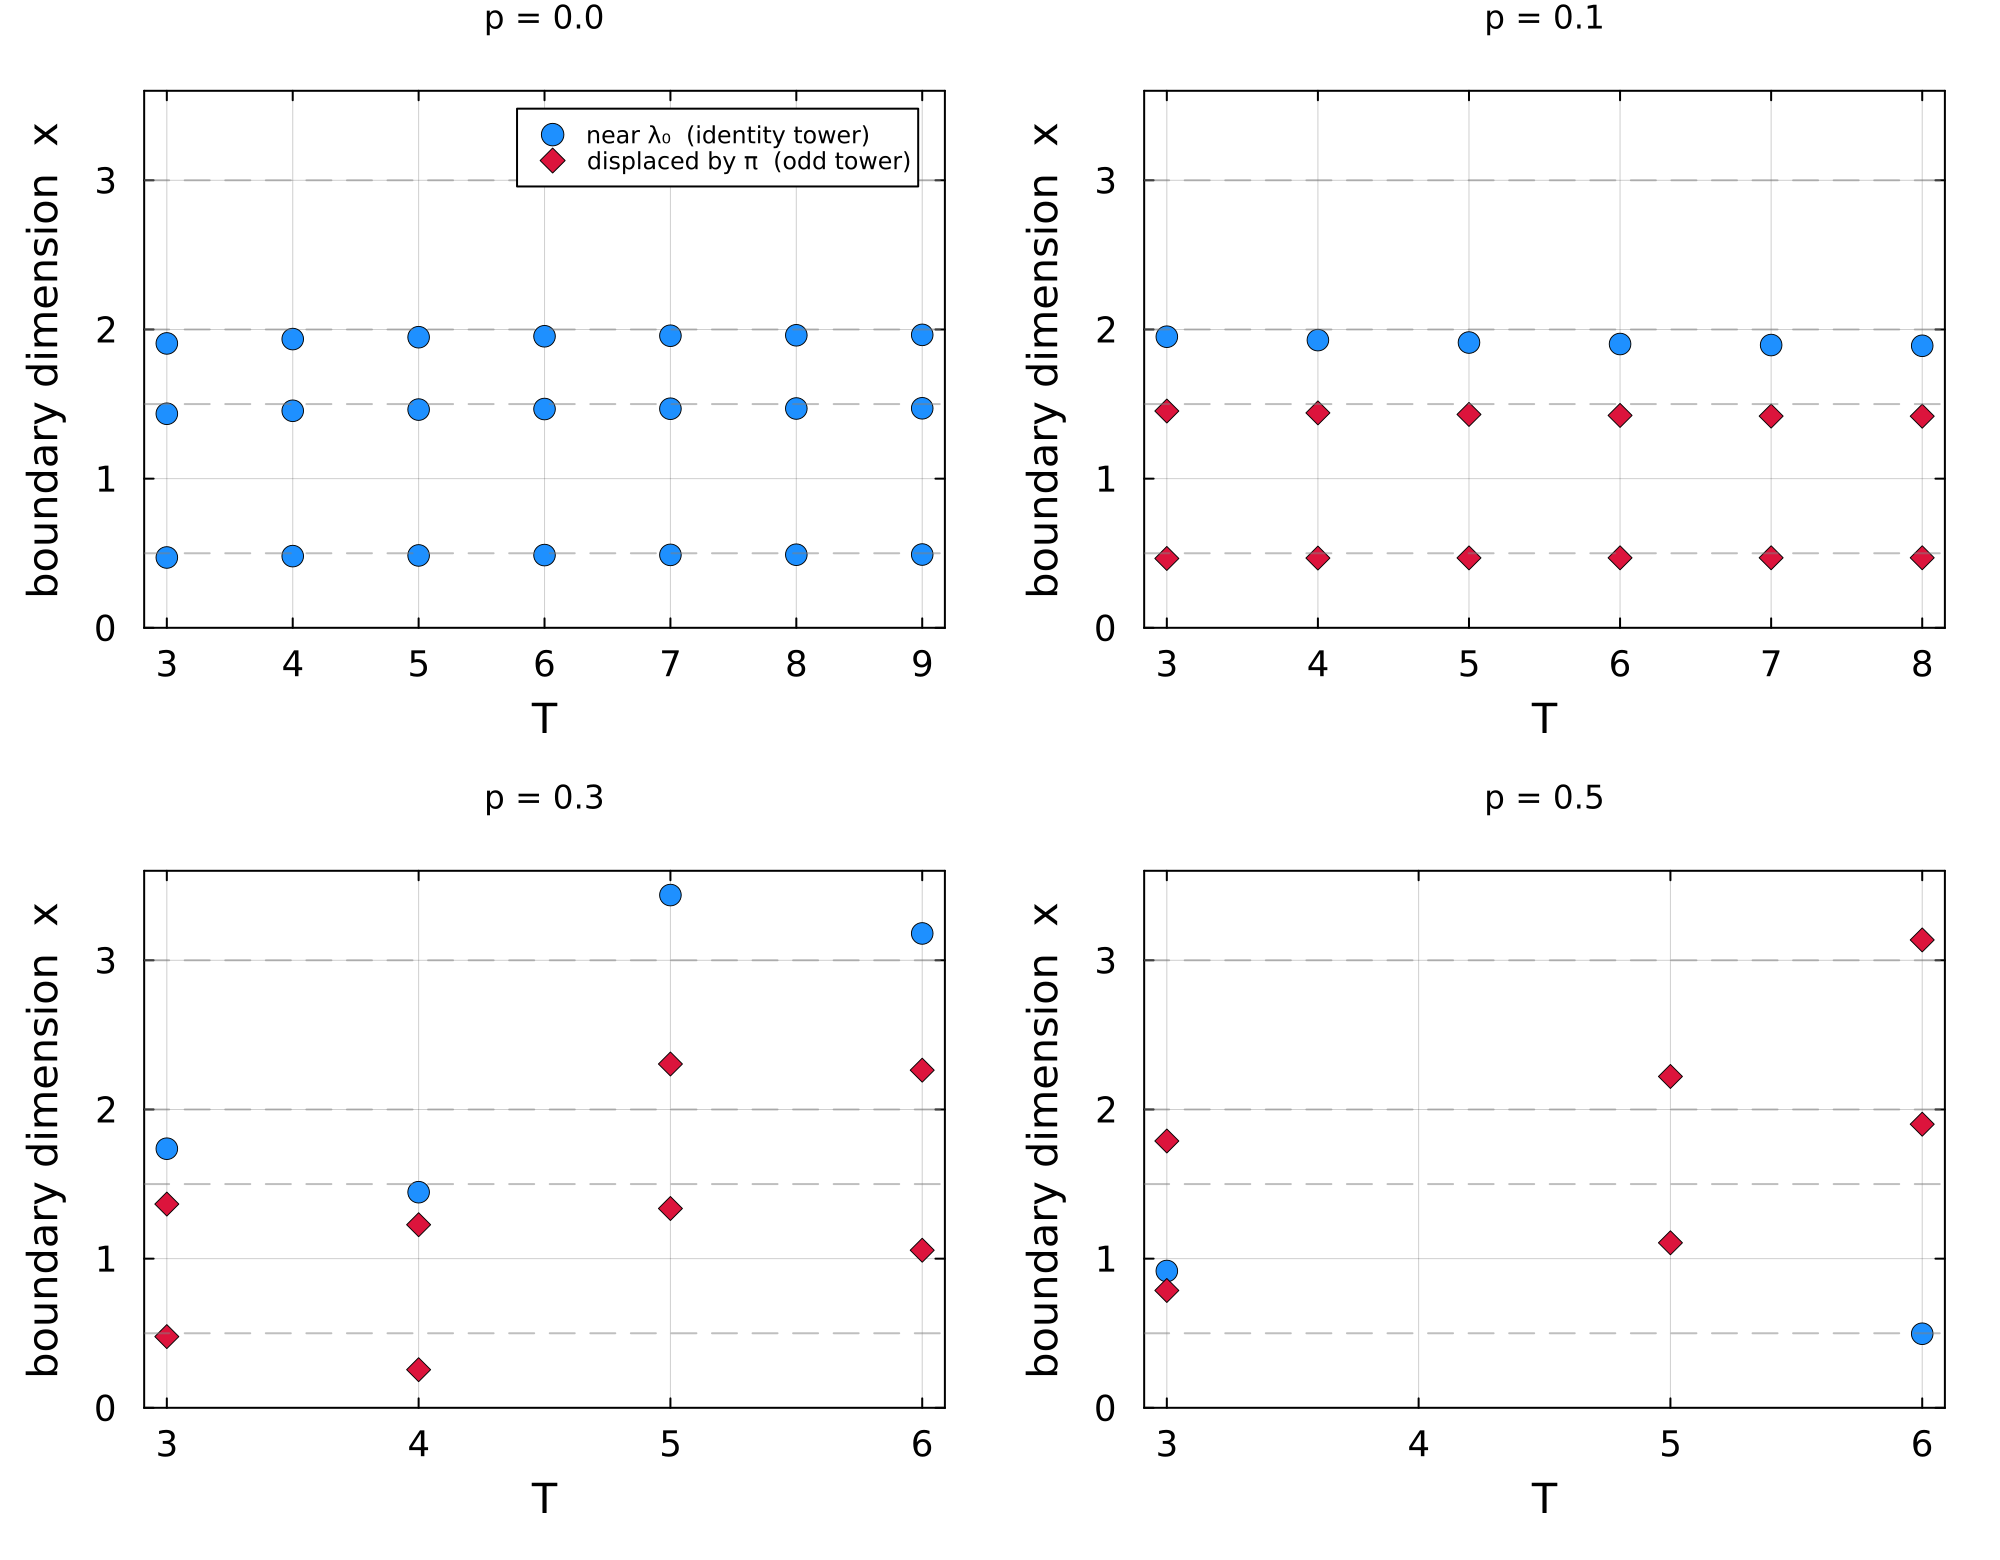

In [16]:
# OPERATOR CONTENT ACROSS p (thesis figure): recover the identity/even tower {2,3,4} sitting near λ0
# AND the momentum-π-displaced odd tower {1/2,3/2} that the interaction switches on. For each captured
# transfer eigenvalue we read its boundary dimension x from the phase gap to λ0 — near-λ0 states
# (|Δφ|<π/2) as x = v(p)·T·|Δφ|/π, π-displaced states as x = v(p)·T·(π−|Δφ|)/π. At p=0 (free fermions)
# the whole free-BC ladder {1/2,3/2,2,…} sits near λ0 and there is NO π-side population; for p≠0 the odd
# ladder jumps to phase ≈π. p=0/0.1 come from nb8_master, p=0.3/0.5 from the cluster sweep.
thesis_plot_theme!()

cluster_done(p) = load("../results/data/cluster/sweep_rtm_p$(p).jld2", "done")
function spectrum_at(p, T)
    if p in (0.0, 0.1)
        (haskey(done, (p, T)) && haskey(done[(p, T)], :theta)) || return nothing
        entry = done[(p, T)]
        return (collect(entry.theta), entry.i0)
    else
        cluster = cluster_done(p)
        key = ("rtm_p$(p)", T)
        (haskey(cluster, key) && haskey(cluster[key], :theta)) || return nothing
        entry = cluster[key]
        return (collect(entry.theta), entry.i0)
    end
end

p_panels  = [0.0, 0.1, 0.3, 0.5]
T_windows = Dict(0.0 => 3.0:1.0:9.0, 0.1 => 3.0:1.0:8.0, 0.3 => 3.0:1.0:6.0, 0.5 => 3.0:1.0:6.0)

tower_across = plot(layout=(2, 2), size=(1000, 780))

for (panel_index, p) in enumerate(p_panels)
    velocity = v_of[p]

    near_T = Float64[]; near_x = Float64[]      # identity / undisplaced ladder (blue)
    disp_T = Float64[]; disp_x = Float64[]      # π-displaced odd ladder (red)

    for T in T_windows[p]
        spec = spectrum_at(p, T)
        spec === nothing && continue
        theta, i0 = spec
        lam0 = theta[i0]
        abs(lam0) < 1.0 && continue             # drop glitched points where |θ0| collapsed

        for j in eachindex(theta)
            j == i0 && continue
            phase_gap = abs(dphw(theta[j], lam0))
            if phase_gap < pi/2
                x = velocity * T * phase_gap / pi
                x > 0.05 && (push!(near_T, T); push!(near_x, x))
            else
                x = velocity * T * (pi - phase_gap) / pi
                x > 0.05 && (push!(disp_T, T); push!(disp_x, x))
            end
        end
    end

    scatter!(tower_across, near_T, near_x; subplot=panel_index, color=:dodgerblue, ms=6, msw=0.3,
             label=(panel_index == 1 ? "near λ₀  (identity tower)" : ""))
    scatter!(tower_across, disp_T, disp_x; subplot=panel_index, color=:crimson, marker=:diamond, ms=6, msw=0.3,
             label=(panel_index == 1 ? "displaced by π  (odd tower)" : ""))

    for x_cft in [0.5, 1.5, 2.0, 3.0]
        hline!(tower_across, [x_cft]; subplot=panel_index, color=:gray, ls=:dash, lw=1, alpha=0.5, label="")
    end

    plot!(tower_across; subplot=panel_index, xlabel="T", ylabel="boundary dimension  x",
          title="p = $p", titlefontsize=11, ylims=(0, 3.6),
          legend=(panel_index == 1 ? :topright : false), legendfontsize=8)
end

mkpath("../results/imgs")
savefig(tower_across, "../results/imgs/alcaraz_tower_across_p.png")
tower_across


The dual reading confirms the picture: at $p=0.1$ the near-$\lambda_0$ state reads $x\approx1.9\approx2$ (the identity module's stress-tensor descendant), and the $\pi$ side gives $x\approx0.47,\,1.44$ ($\approx1/2,\,3/2$) (the odd ladder), all stable in $T$. 

Both towers, read with the true $v(p)$, are clean CFT content

## Summary

Temporal Ising universality survives the NNN frustration at $p=0.1$. The central charge is $c\approx1/2$ by several independent reads: the calibrated Rényi-2 entropy slope ($0.48\pm0.05$), the calibrated Eq. (3) eigenvalue curvature ($0.52$), the **absolute** imaginary-plateau read (paper-consistent $\pi c/16$ + finite-time correction, $0.57$ at $T\le12$ and converging to $\tfrac12$), and the partner-inclusive Eq. (4) boundary exponent ($0.47$). The full transfer spectrum, read with the measured velocity $v(p)$, is clean CFT content: the identity module $\{2,3,4,\ldots\}$ at phase $0$ plus the boundary-fermion ladder $\{1/2,3/2,\ldots\}$ displaced by momentum $\pi$; and the boundary exponent is $x_1=1/2$ once that displacement is accounted for.

| route | $p=0$ | $p=0.1$ |
|---|---|---|
| Rényi-2 slope ($c=8\cdot$slope, calibrated) | $\equiv1/2$ (calibration) | $0.48\pm0.05$ ✅ |
| imaginary plateau ($\pi c/16$ + fin.-$T$ corr., **absolute**) | $0.57\to\tfrac12$ ✅ | wall $\Rightarrow$ eigenvalue route |
| Eq. (3) $\lambda_0$ curvature (calibrated) | $\equiv1/2$ (calibration) | $0.52$ ✅ |
| Eq. (4) $x_1$ (partner-inclusive) | $0.49$ | $0.47\approx1/2$ ✅ |

The finite-time correction is the through-line: it explains the log-only $\approx0.67$ (Route 1) and the plateau's downward drift (Route 1b), it is why the calibrated ratio is robust (the correction cancels), and it is what the absolute read must include. This is exactly the machinery of Bou-Comas, Carignano *et al.* (2026).

**Still open questions:**
- the absolute $c$ at $p=0.1$ and beyond: the entropy dome walls, so this is deferred to the eigenvalue route on the wider cluster window (Eq. 3 absolute $c$, and the `eigsweep` $p$-sweep) — the $B\!-\!C$ fit degeneracy that limits the pre-wall absolute read needs the long $T$-baseline;
- the absolute $c(p=0)$ benchmark to $\approx0.52$: pending the high-$T$ $p=0$ cluster run (our asymmetric MPO, $T\to20$);
- the $p=0.3/0.5$ tower identifications (cluster $p$-sweep, the ready cell below);
- the mechanism behind the $\pi$-displaced partners (the Kramers-Wannier/Majorana derivation, the XY velocity-faithfulness control, the single-term dissection pinning the NNN hop) is developed in `pairing_partners.ipynb`; the deeper $k=8/10$ ladders are in NB3.

### Ready for the cluster $p$-sweep

The warm 8-job cluster sweep extends this to $p=0.3,0.5,\ldots$ and to $T=14$ (breaking the Eq. 3 $B-C$ fit degeneracy that limits the absolute read at $p=0.1$). The cell below runs the same partner-inclusive tower/ratio analysis automatically once `warm_sweep.jld2` lands.

In [17]:
# CLUSTER-READY: partner-inclusive tower reading of the warm p-sweep, the moment
# results/data/cluster/warm_sweep.jld2 lands (v3 labels rtm_p<p>; p=0.3/0.5 arbitration + T≤20 window).
cluster_file = "../results/data/cluster/warm_sweep.jld2"
if isfile(cluster_file)
    cluster_data = load(cluster_file, "done")
    # v(p) for the p-sweep points, extending the NB4 cache linearly where a point is missing
    v_cluster(p) = haskey(v_of, p) ? v_of[p] : 2.0 + 1.2*(p - 0.0)
    println("warm sweep: $(length(cluster_data)) entries — smallest boundary dim (partner-inclusive) per (label,T):")
    for p in [0.0, 0.1, 0.3, 0.5, 0.8, 1.0, 1.5]
        label = "rtm_p$(p)"
        Ts = sort([k[2] for k in keys(cluster_data) if k[1] == label && haskey(cluster_data[k], :theta)])
        isempty(Ts) && continue
        v_here = v_cluster(p)
        row = String[]
        for T in Ts
            e = cluster_data[(label, T)]
            i0 = e.i0; lam0 = e.theta_phys
            dims = Float64[]
            for j in eachindex(e.theta)
                j == i0 && continue
                g = abs(dphw(e.theta[j], lam0))
                x = g < pi/2 ? v_here*T*g/pi : v_here*T*(pi-g)/pi
                x > 0.05 && push!(dims, x)
            end
            isempty(dims) || push!(row, @sprintf("T%d:%.2f", Int(T), minimum(dims)))
        end
        @printf("  %-9s (v≈%.2f): x₁ = %s\n", label, v_here, join(row, "  "))
    end
else
    println("cluster warm_sweep.jld2 not yet available — rerun this cell once the p-sweep lands (assemble it with cluster/merge_sweeps.jl).")
end

cluster warm_sweep.jld2 not yet available — rerun this cell once the p-sweep lands (assemble it with cluster/merge_sweeps.jl).


### Appendix — fixed boundary condition

As a control, the fixed BC ($|Z+\rangle$) should give $x_1=2$ (a different boundary CFT), not $1/2$.

In [18]:
# Fixed-BC (|Up⟩) x1 extraction on Alcaraz. 

fixedbc_cachefile = "../results/data/nb7_alcaraz_fixedbc.jld2"
fixedbc = isfile(fixedbc_cachefile) ? load(fixedbc_cachefile, "done") : Dict{Tuple{Float64,Float64},Any}()

T_ladder_fixed = [2.0, 3.0, 4.0, 5.0, 6.0]

for p in p_list
    previous_physical = nothing
    for T in T_ladder_fixed
        if haskey(fixedbc, (p, T)) && !haskey(fixedbc[(p, T)], :error)
            previous_physical = fixedbc[(p, T)].theta_phys
            continue
        end
        try
            # Fixed BC = the σz eigenstate |Up⟩
            mpo, scaffold = build_tmpo(AlcarazParams(lambda=1.0, p=p), AlcarazVD2(), T;
                                       dt=dt, nbeta=nbeta, init_state="Up")
            theta, _, _, info = block_transfer_eigs(
                mpo, scaffold;
                k=4, maxdim=64, maxdims=collect(2:2:64),
                cutoff=1e-12, cutoffs=[fill(1e-8, 40); 1e-10],
                itermax=4000, eps_conv=1e-6, trunc_mode=:rtm, n_track=2, stuck_after=300)

            # Physical λ0 by continuity
            if previous_physical === nothing
                physical_index = argmax(abs.(theta))
            else
                physical_index = argmin(abs.(theta .- previous_physical))
            end

            fixedbc[(p, T)] = (theta=collect(theta), i0=physical_index,
                               theta_phys=theta[physical_index], reason=string(info[:reason]))
            previous_physical = theta[physical_index]
            @info "fixed-BC Alcaraz p=$p T=$T  i0=$physical_index  $(info[:reason])"
        catch err
            @warn "fixed-BC Alcaraz p=$p T=$T failed: $err"
            fixedbc[(p, T)] = (error=string(err),)
            previous_physical = nothing
        end
        jldsave(fixedbc_cachefile; done=fixedbc)
        GC.gc()
    end
end

# x1 from Im(λ1 - λ0), λ1 phase-closest to the physical λ0
function fixedbc_x1(p; Tmax=6.0)
    times = sort([T for T in T_ladder_fixed
                  if haskey(fixedbc, (p, T)) && !haskey(fixedbc[(p, T)], :error) && T <= Tmax])
    phase_gaps = Float64[]

    for T in times
        entry = fixedbc[(p, T)]
        candidates   = [j for j in eachindex(entry.theta) if j != entry.i0]
        gaps_to_phys = [dphw(entry.theta[j], entry.theta_phys) for j in candidates]
        descendant   = candidates[argmin(abs.(gaps_to_phys))]
        push!(phase_gaps, dphw(entry.theta[descendant], entry.theta_phys))
    end

    fit_model(T, q) = q[1] ./ T .+ q[2] ./ T.^3
    fit = curve_fit(fit_model, Float64.(times), phase_gaps, [-1.0, 0.0])

    return (; times, phase_gaps, a1=fit.param[1], x1=abs(v_of[p] * fit.param[1] / pi))
end

@printf("Fixed-BC (|Up⟩) boundary exponent on Alcaraz:\n")
for p in p_list
    have = [T for T in T_ladder_fixed if haskey(fixedbc, (p, T)) && !haskey(fixedbc[(p, T)], :error)]
    length(have) >= 3 || (println("  p=$p: incomplete"); continue)
    fit = fixedbc_x1(p)
    @printf("  p=%.1f : fixed-BC x1 = %.3f   (a1 = %.3f)\n", p, fit.x1, fit.a1)
    println("    Im(λ1-λ0) per T: ", round.(fit.phase_gaps, digits=4), "  (i0 per T: ",
            [fixedbc[(p,T)].i0 for T in fit.times], ")")
end

Fixed-BC (|Up⟩) boundary exponent on Alcaraz:
  p=0.0 : fixed-BC x1 = 1.977   (a1 = 3.141)


    Im(λ1-λ0) per T: 

[1.4287, 1.0079, 0.7675, 0.6178, 0.5164]  (i0 per T: [1, 1, 1, 1, 1])
  p=0.1 : fixed-BC x1 = 1.698   (a1 = -2.052)
    Im(λ1-λ0) per T: [-1.8842, -0.7757, -0.4128, -0.9805, -0.2285]  (i0 per T: [1, 1, 2, 4, 4])


### p=0 spectral validation figures (Alcaraz construction)

The spectral route validates the pipeline at $p=0$ using the **same Alcaraz construction** as every other $p$ — unlike the entropy dome, the eigenvalue reads are clean here (no finite-time inflation). Three figures: the $\mu_0$ circle (emergent dual unitarity), the Eq.~(3) phase-curvature fit for the central charge, and the Eq.~(4) boundary exponent for the free ($|X+\rangle$) and fixed ($|\mathrm{Up}\rangle$) boundary conditions. All loop over the cached $T$, so the longer $p=0$ cluster run re-plots them.

p=0 spectral validation:  |λ₀|=1.4891 ;  Eq.(3) c_direct=0.4808 ;  x₁(free)=0.4933 ;  x₁(fixed)=1.9767


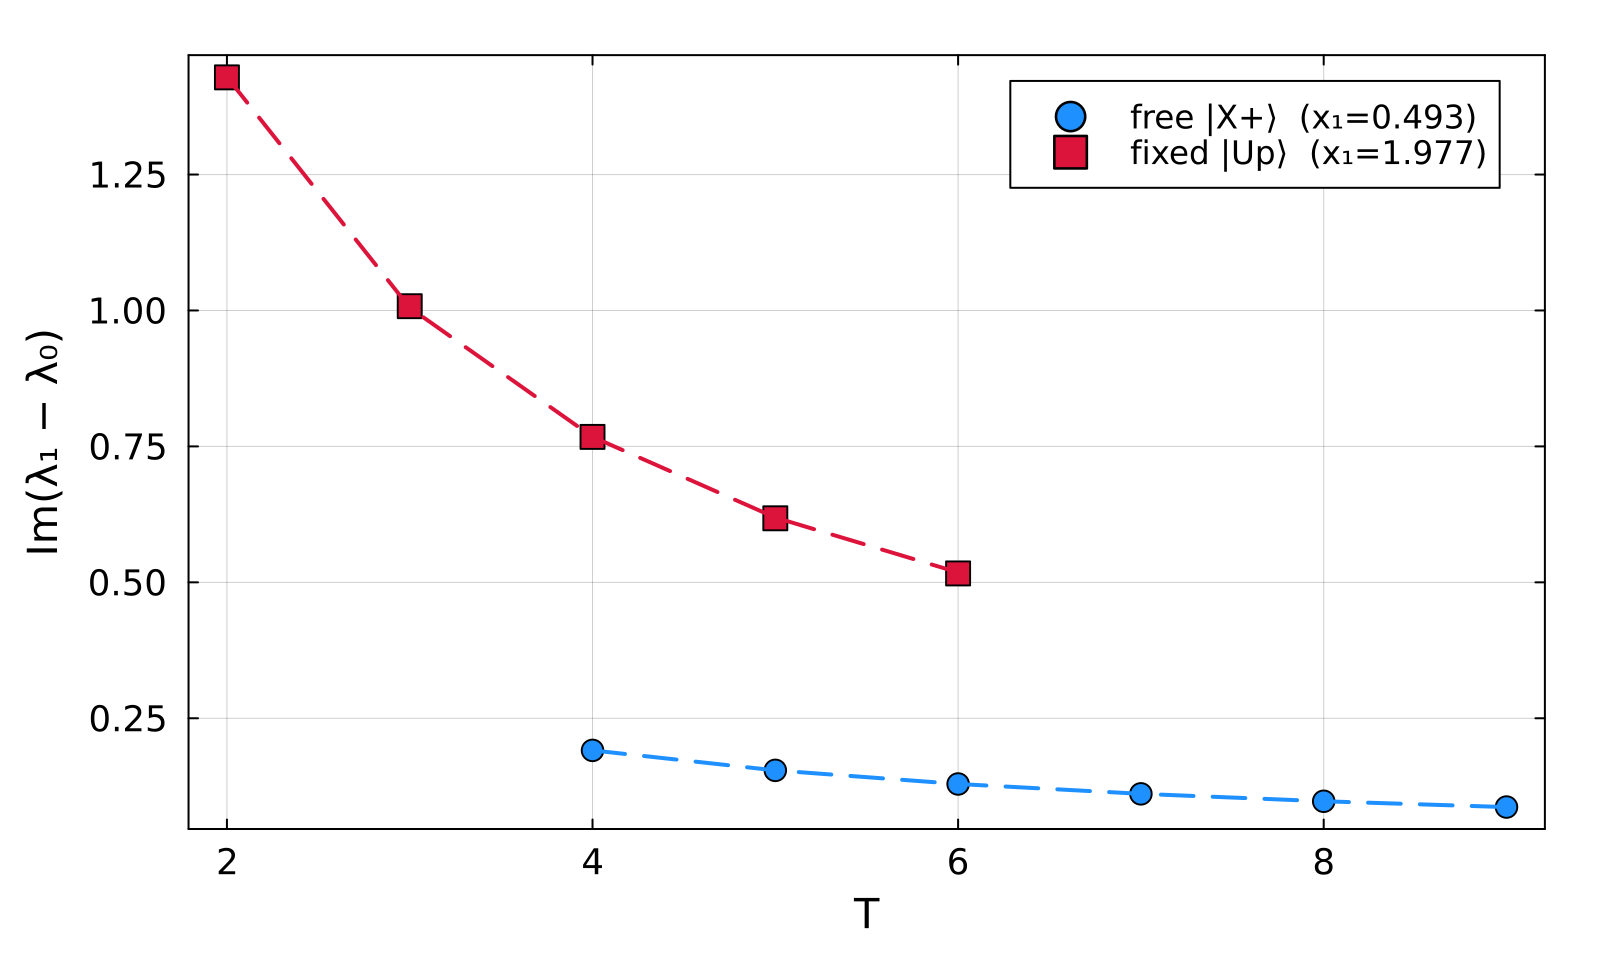

In [19]:
thesis_plot_theme!()

# ===== (1) p=0 λ₀ circle — emergent dual unitarity =====
p0_times = times_for_parameter(0.0)
lam0_p0  = [done[(0.0, T)].theta_phys for T in p0_times]
radius0  = sum(abs, lam0_p0) / length(lam0_p0)
ref_ph   = range(0, 2pi, length=400)

circle_p0 = plot(aspect_ratio=:equal, xlabel="Re λ₀", ylabel="Im λ₀",
                 framestyle=:box, grid=true, legend=:inside, size=(560, 540))
plot!(circle_p0, radius0 .* cos.(ref_ph), radius0 .* sin.(ref_ph);
      ls=:dash, color=:dodgerblue, lw=1, alpha=0.6, label="")
scatter!(circle_p0, real.(lam0_p0), imag.(lam0_p0);
         color=:dodgerblue, marker=:circle, ms=6, msw=0.5,
         label="p=0   (|λ₀| ≈ $(round(radius0, digits=3)))")
mkpath("../results/imgs")
savefig(circle_p0, "../results/imgs/val_circle_p0.png")

# ===== (2) p=0 Eq.(3) phase curvature → c = 24·v·|C|/π =====
times3, imph3, coeffs3 = fit_coeffs(0.0)      # helper defined in the Eq.(3) fit cell above
A3, C3, D3 = coeffs3
c_direct_p0 = 24 * v_of[0.0] * abs(C3) / pi

eq3_p0 = plot(xlabel="T", ylabel="(Im(λ₀) + π) / T", framestyle=:box, grid=true, legend=:right)
scatter!(eq3_p0, times3, imph3 ./ times3; color=:blue, marker=:circle, ms=6, label="p=0  data")
Tdense = range(minimum(times3), maximum(times3), length=200)
plot!(eq3_p0, Tdense, A3 .+ C3 ./ Tdense.^2 .+ D3 ./ Tdense.^4;
      color=:blue, lw=2, ls=:dash, label="fit  c=$(round(c_direct_p0, digits=3))")
savefig(eq3_p0, "../results/imgs/val_eq3_p0.png")

# ===== (3) p=0 boundary exponent: free |X+⟩ vs fixed |Up⟩ =====
# At p=0 the odd tower sits near λ₀, so the naive nearest-phase gap already gives the free x₁≈1/2.
@. gap_model(T, q) = q[1]/T + q[2]/T^3
function free_gap(T)
    e = done[(0.0, T)]
    cand = [j for j in eachindex(e.theta) if j != e.i0]
    gaps = [dphw(e.theta[j], e.theta_phys) for j in cand]
    return dphw(e.theta[cand[argmin(abs.(gaps))]], e.theta_phys)
end
free_T   = [T for T in p0_times if 4.0 <= T <= 9.0]
free_g   = [free_gap(T) for T in free_T]
free_fit = curve_fit(gap_model, Float64.(free_T), free_g, [-1.0, 0.0])
x1_free  = abs(v_of[0.0] * free_fit.param[1] / pi)

fx = fixedbc_x1(0.0)                            # fixed BC |Up⟩, helper from the appendix cell

x1_plot = plot(xlabel="T", ylabel="Im(λ₁ − λ₀)", framestyle=:box, grid=true, legend=:topright)
scatter!(x1_plot, free_T, free_g; color=:dodgerblue, marker=:circle, ms=6,
         label="free |X+⟩  (x₁=$(round(x1_free, digits=3)))")
plot!(x1_plot, free_T, gap_model(Float64.(free_T), free_fit.param); color=:dodgerblue, lw=2, ls=:dash, label="")
scatter!(x1_plot, fx.times, fx.phase_gaps; color=:crimson, marker=:square, ms=6,
         label="fixed |Up⟩  (x₁=$(round(fx.x1, digits=3)))")
fixed_fit = curve_fit(gap_model, Float64.(fx.times), fx.phase_gaps, [-1.0, 0.0])
plot!(x1_plot, fx.times, gap_model(Float64.(fx.times), fixed_fit.param); color=:crimson, lw=2, ls=:dash, label="")
savefig(x1_plot, "../results/imgs/val_x1_p0.png")

@printf("p=0 spectral validation:  |λ₀|=%.4f ;  Eq.(3) c_direct=%.4f ;  x₁(free)=%.4f ;  x₁(fixed)=%.4f\n",
        radius0, c_direct_p0, x1_free, fx.x1)
x1_plot

The fixed BC gives $x_1(p{=}0)=1.98\approx2$, which corresponds to a different boundary CFT, exactly the expected value, confirming that our $|X^+\rangle$ quench is the free boundary used throughout.